# Company Large Group Close Ratio Improvement
## Exploratory Data Analysis

**Prepared by:** Ed Underberg  
**Work Sample:** Strategic Sales Channel Analyst

### Business Question
Large Group new-business close rate declined from **55% in 2025 to 25% in 2026** in this fictional dataset.

1. **H1 — 2025 Pull-Forward + Relationship Disruption:** Did the subsequent retirement of two long-tenured sellers contribute to relationship disruption and lower conversion?
2. **H2 — Changing Opportunity & Engagement Mix:** Did changes in opportunity composition, engagement behavior, and new-product emphasis contribute to lower conversion?
3. **H3 — Relative Pricing Deterioration:** Did a less favorable relative pricing position reduce win probability?

### Dependent Variable
**Outcome = Won or Lost**. Numerically, `Won`: `1 = Won`, `0 = Lost`.

This notebook performs exploratory data analysis to identify patterns for subsequent statistical testing.

## Data Source & Analytical Unit
- **File:** `Company_Large_Group_Data_Table.csv`
- **Analytical unit:** one qualified new Large Group sales opportunity
- **Years:** 2025 and 2026
- **Geography:** Iowa and South Dakota
- **Large Group:** more than 50 eligible employees

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

pd.set_option("display.max_columns", None)

### Load and Prepare Data

In [2]:
df = pd.read_csv("Company_Large_Group_Data_Table.csv")

df["Estimated_Annual_Premium"] = (
    df["Estimated_Annual_Premium"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

df["Won"] = df["Won"].astype(int)

df["Meaningful_Engagement_Rate"] = (
    df["Meaningful_Engagements"] / df["Total_Activities"]
)

target = "Won"

df.info()
print("\nDataset shape:", df.shape)
print("\nMissing values:")
display(df.isna().sum()[df.isna().sum() > 0])
display(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Opportunity_ID                200 non-null    str    
 1   Company_Name                  200 non-null    str    
 2   Year                          200 non-null    int64  
 3   Quarter                       200 non-null    str    
 4   State                         200 non-null    str    
 5   Industry                      200 non-null    str    
 6   Salesperson                   200 non-null    str    
 7   Lead_Source                   200 non-null    str    
 8   Size_Segment                  200 non-null    str    
 9   Employee_Count                200 non-null    int64  
 10  Publicly_Traded               200 non-null    str    
 11  Relationship_Maturity         200 non-null    str    
 12  Inherited_Relationship        200 non-null    str    
 13  New_Product_Pres

New_Product_Presented    100
dtype: int64

,Opportunity_ID,Company_Name,Year,Quarter,State,Industry,Salesperson,Lead_Source,Size_Segment,Employee_Count,Publicly_Traded,Relationship_Maturity,Inherited_Relationship,New_Product_Presented,In_Person,Lunches,Teams,Phone_Calls,Drop_Ins,Entertaining,Emails,Voicemails,Texts,Meaningful_Engagements,Low_Touch_Activities,Total_Activities,Company_Rate_Increase_Pct,Competitor_Rate_Increase_Pct,Rate_Differential_Points,Estimated_Annual_Premium,Won,Outcome,Meaningful_Engagement_Rate
0,LG-2025-001,Cedar Works,2025,Q1,South Dakota,Manufacturing,Derek,Sales Prospecting,Middle Market,659,No,Developing,No,NaN,0,0,1,1,0,0,4,3,0,2,7,9,6.29,5.84,0.45,6939000.0,0,Lost,0.222222
1,LG-2025-002,Bridge Supply,2025,Q1,South Dakota,Transportation & Logistics,Carol,Marketing Inbound,Lower Market,84,No,Developing,No,NaN,1,1,0,1,0,0,6,0,1,3,7,10,4.55,4.87,-0.32,916000.0,0,Lost,0.300000
2,LG-2025-003,Northstar Enterprises,2025,Q1,Iowa,Manufacturing,Sarah,Broker / Agent Referral,Middle Market,861,No,Established,No,NaN,2,0,0,1,0,1,3,1,0,4,4,8,6.12,5.53,0.59,9794000.0,0,Lost,0.500000
3,LG-2025-004,Silver AgriServices,2025,Q1,Iowa,Manufacturing,Marcus,Marketing Inbound,Lower Market,400,No,Established,No,NaN,0,0,2,1,0,2,5,1,0,5,6,11,5.43,4.81,0.62,4945000.0,0,Lost,0.454545
4,LG-2025-005,Hawkeye Industries,2025,Q1,Iowa,Construction,Derek,Marketing Inbound,Lower Market,205,No,Established,No,NaN,1,1,2,2,0,1,4,1,2,7,7,14,4.93,6.13,-1.20,2078000.0,1,Won,0.500000


### Data Quality Note
`New_Product_Presented` is not applicable to 2025 because the fictional product launches in 2026.

## Baseline Outcome

,Opportunities,Wins,Losses,Close_Rate
Year,,,,
2025,100,55,45,0.55
2026,100,25,75,0.25


Opportunities  Wins  Close_Rate
Year Quarter                                 
2025 Q1                  20     8        0.40
     Q2                  30    21        0.70
     Q3                  30    18        0.60
     Q4                  20     8        0.40
2026 Q1                  20     5        0.25
     Q2                  30     9        0.30
     Q3                  30     6        0.20
     Q4                  20     5        0.25

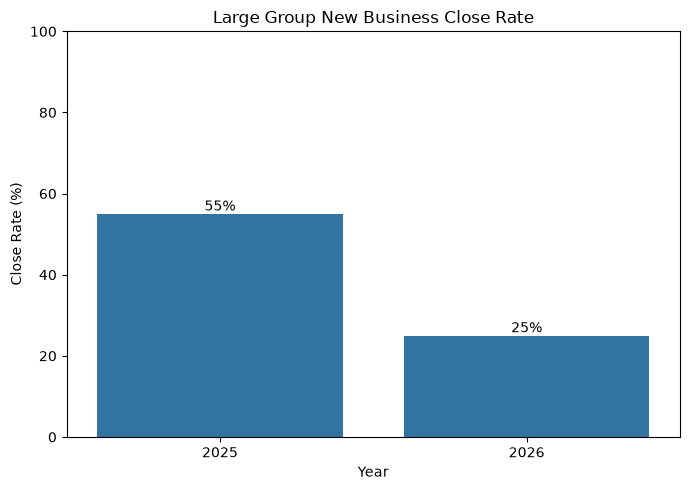

In [3]:
annual_summary = df.groupby("Year").agg(
    Opportunities=("Opportunity_ID", "count"),
    Wins=("Won", "sum")
)
annual_summary["Losses"] = annual_summary["Opportunities"] - annual_summary["Wins"]
annual_summary["Close_Rate"] = annual_summary["Wins"] / annual_summary["Opportunities"]

quarter_summary = df.groupby(["Year", "Quarter"]).agg(
    Opportunities=("Opportunity_ID", "count"),
    Wins=("Won", "sum")
)
quarter_summary["Close_Rate"] = quarter_summary["Wins"] / quarter_summary["Opportunities"]

display(annual_summary)
display(quarter_summary)

close_rate_year = df.groupby("Year")["Won"].mean().reset_index()
close_rate_year["Close_Rate_Pct"] = close_rate_year["Won"] * 100

plt.figure(figsize=(7, 5))
ax = sns.barplot(data=close_rate_year, x="Year", y="Close_Rate_Pct")
plt.title("Large Group New Business Close Rate")
plt.xlabel("Year")
plt.ylabel("Close Rate (%)")
plt.ylim(0, 100)

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.0f}%",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center", va="bottom"
    )

plt.tight_layout()
plt.show()

# Data Cleansing and Analytical Transformations

Prepare one clean analytical dataset before exploratory analysis. Transformations are created once here and reused throughout the notebook.

In [4]:
# Work from a clean copy
df = df.copy()

# Clean column names
df.columns = df.columns.str.strip()

# Convert Estimated Annual Premium to numeric if loaded from currency-formatted CSV text
if df["Estimated_Annual_Premium"].dtype == "object":
    df["Estimated_Annual_Premium"] = (
        df["Estimated_Annual_Premium"]
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.strip()
    )

df["Estimated_Annual_Premium"] = pd.to_numeric(
    df["Estimated_Annual_Premium"],
    errors="coerce"
)

# Confirm analytical numeric fields are numeric
numeric_vars = [
    "Year",
    "Employee_Count",
    "Estimated_Annual_Premium",
    "Total_Activities",
    "Meaningful_Engagements",
    "Low_Touch_Activities",
    "Rate_Differential_Points",
    "Won"
]

for var in numeric_vars:
    df[var] = pd.to_numeric(df[var], errors="coerce")

# Derived engagement measure
df["Meaningful_Engagement_Rate"] = np.where(
    df["Total_Activities"] > 0,
    df["Meaningful_Engagements"] / df["Total_Activities"],
    np.nan
)

# Standardize categorical text
categorical_vars = [
    "Quarter",
    "Outcome",
    "Size_Segment",
    "Lead_Source",
    "State",
    "Industry",
    "Publicly_Traded",
    "Relationship_Maturity",
    "Inherited_Relationship",
    "Salesperson",
    "New_Product_Presented"
]

for var in categorical_vars:
    df[var] = df[var].astype("string").str.strip()

# Preserve quarter order
quarter_order = ["Q1", "Q2", "Q3", "Q4"]
df["Quarter"] = pd.Categorical(
    df["Quarter"],
    categories=quarter_order,
    ordered=True
)

# Validate the cleaned analytical dataset
print("Dataset shape:", df.shape)
print("\nMissing values in analytical variables:")

validation_vars = numeric_vars + ["Meaningful_Engagement_Rate"] + categorical_vars

display(
    df[validation_vars]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

print("\nOutcome validation:")
display(
    df.groupby("Year", observed=False)
      .agg(
          Opportunities=("Won", "size"),
          Wins=("Won", "sum"),
          Close_Rate=("Won", "mean")
      )
)

Dataset shape: (200, 33)

Missing values in analytical variables:


New_Product_Presented         100
Year                            0
Estimated_Annual_Premium        0
Employee_Count                  0
Total_Activities                0
Meaningful_Engagements          0
Rate_Differential_Points        0
Low_Touch_Activities            0
Meaningful_Engagement_Rate      0
Quarter                         0
Outcome                         0
Won                             0
Size_Segment                    0
Lead_Source                     0
Industry                        0
State                           0
Publicly_Traded                 0
Relationship_Maturity           0
Inherited_Relationship          0
Salesperson                     0
dtype: int64


Outcome validation:


,Opportunities,Wins,Close_Rate
Year,,,
2025,100,55,0.55
2026,100,25,0.25


# Python Broad Exploratory Data Analysis

Before investigating H1, H2, and H3 individually, screen the continuous variables for their distributions and their univariate association with `Won`. Because `Won` is coded 0/1, Pearson correlation with a continuous variable is equivalent to the point-biserial correlation.

The business question is the change from 2025 to 2026, so correlations are compared by year rather than pooled across both years.


In [5]:
# ============================================================
# BROAD EDA ASSOCIATION SCREEN
# ============================================================
# Purpose:
# Screen all available numeric measures and categorical
# dimensions for changes in their association with Won
# from 2025 to 2026.
#
# Numeric Measures:
#   Pearson correlation with binary Won (point-biserial r)
#
# Categorical Dimensions:
#   Cramer's V association with Won
#
# IMPORTANT:
# Pearson r and Cramer's V are different statistics.
# This table is an exploratory screening tool used to identify
# variables for deeper investigation, not a formal comparison
# of statistical effect sizes.
# ============================================================

from scipy.stats import chi2_contingency


# ------------------------------------------------------------
# 1. DEFINE NUMERIC MEASURES
# ------------------------------------------------------------

continuous_vars = [
    "Employee_Count",
    "In_Person",
    "Lunches",
    "Teams",
    "Phone_Calls",
    "Drop_Ins",
    "Entertaining",
    "Emails",
    "Voicemails",
    "Texts",
    "Meaningful_Engagements",
    "Low_Touch_Activities",
    "Total_Activities",
    "Company_Rate_Increase_Pct",
    "Competitor_Rate_Increase_Pct",
    "Rate_Differential_Points",
    "Estimated_Annual_Premium",
    "Meaningful_Engagement_Rate"
]


# ------------------------------------------------------------
# 2. DEFINE CATEGORICAL DIMENSIONS
# ------------------------------------------------------------

categorical_vars = [
    "Quarter",
    "State",
    "Industry",
    "Salesperson",
    "Lead_Source",
    "Size_Segment",
    "Publicly_Traded",
    "Relationship_Maturity",
    "Inherited_Relationship"
]


# ------------------------------------------------------------
# 3. NUMERIC-MEASURE ASSOCIATIONS WITH WON
# ------------------------------------------------------------

corr_2025 = (
    df[df["Year"] == 2025][continuous_vars + ["Won"]]
    .corr(numeric_only=True)["Won"]
    .drop("Won")
    .rename("2025")
)

corr_2026 = (
    df[df["Year"] == 2026][continuous_vars + ["Won"]]
    .corr(numeric_only=True)["Won"]
    .drop("Won")
    .rename("2026")
)

numeric_association = pd.concat(
    [corr_2025, corr_2026],
    axis=1
)

numeric_association["Variable Type"] = "Numeric Measure"


# ------------------------------------------------------------
# 4. FUNCTION FOR CATEGORICAL-DIMENSION ASSOCIATIONS
# ------------------------------------------------------------

def cramers_v(data, categorical_col, outcome_col="Won"):

    subset = data[
        [categorical_col, outcome_col]
    ].dropna()

    contingency = pd.crosstab(
        subset[categorical_col],
        subset[outcome_col]
    )

    if contingency.shape[0] < 2 or contingency.shape[1] < 2:
        return np.nan

    chi2 = chi2_contingency(
        contingency,
        correction=False
    )[0]

    n = contingency.to_numpy().sum()
    r, k = contingency.shape

    denominator = min(k - 1, r - 1)

    if n == 0 or denominator == 0:
        return np.nan

    return np.sqrt(
        (chi2 / n) / denominator
    )


# ------------------------------------------------------------
# 5. CATEGORICAL-DIMENSION ASSOCIATIONS WITH WON
# ------------------------------------------------------------

cramers_2025 = pd.Series(
    {
        col: cramers_v(
            df[df["Year"] == 2025],
            col
        )
        for col in categorical_vars
    },
    name="2025"
)

cramers_2026 = pd.Series(
    {
        col: cramers_v(
            df[df["Year"] == 2026],
            col
        )
        for col in categorical_vars
    },
    name="2026"
)

categorical_association = pd.concat(
    [cramers_2025, cramers_2026],
    axis=1
)

categorical_association["Variable Type"] = "Categorical Dimension"


# ------------------------------------------------------------
# 6. COMBINE NUMERIC MEASURES AND CATEGORICAL DIMENSIONS
# ------------------------------------------------------------

association_table = pd.concat(
    [
        numeric_association,
        categorical_association
    ]
)

association_table["Change_2026_vs_2025"] = (
    association_table["2026"]
    - association_table["2025"]
)

association_table["Abs_Change"] = (
    association_table[
        "Change_2026_vs_2025"
    ].abs()
)


# ------------------------------------------------------------
# 7. RANK BY LARGEST CHANGE IN ASSOCIATION
# ------------------------------------------------------------

association_table = (
    association_table
    .sort_values(
        "Abs_Change",
        ascending=False
    )
    .reset_index()
    .rename(
        columns={"index": "Attribute"}
    )
)

association_table = association_table[
    [
        "Attribute",
        "Variable Type",
        "2025",
        "2026",
        "Change_2026_vs_2025",
        "Abs_Change"
    ]
]


# ------------------------------------------------------------
# 8. DISPLAY BROAD SCREEN
# ------------------------------------------------------------

display(
    association_table
    .drop(columns="Abs_Change")
    .round(3)
)

print(
    f"{len(continuous_vars)} numeric measures + "
    f"{len(categorical_vars)} categorical dimensions = "
    f"{len(association_table)} attributes analyzed"
)

,Attribute,Variable Type,2025,2026,Change_2026_vs_2025
0,Meaningful_Engagement_Rate,Numeric Measure,0.048,0.340,0.292
1,Teams,Numeric Measure,-0.109,0.138,0.246
2,Competitor_Rate_Increase_Pct,Numeric Measure,0.147,-0.046,-0.194
3,Emails,Numeric Measure,0.012,-0.172,-0.184
4,Meaningful_Engagements,Numeric Measure,0.150,0.327,0.177
5,Quarter,Categorical Dimension,0.258,0.089,-0.169
6,Entertaining,Numeric Measure,-0.173,-0.014,0.159
7,Company_Rate_Increase_Pct,Numeric Measure,0.008,-0.147,-0.155
8,Employee_Count,Numeric Measure,-0.081,0.065,0.146
9,Estimated_Annual_Premium,Numeric Measure,-0.047,0.095,0.142


18 numeric measures + 9 categorical dimensions = 27 attributes analyzed


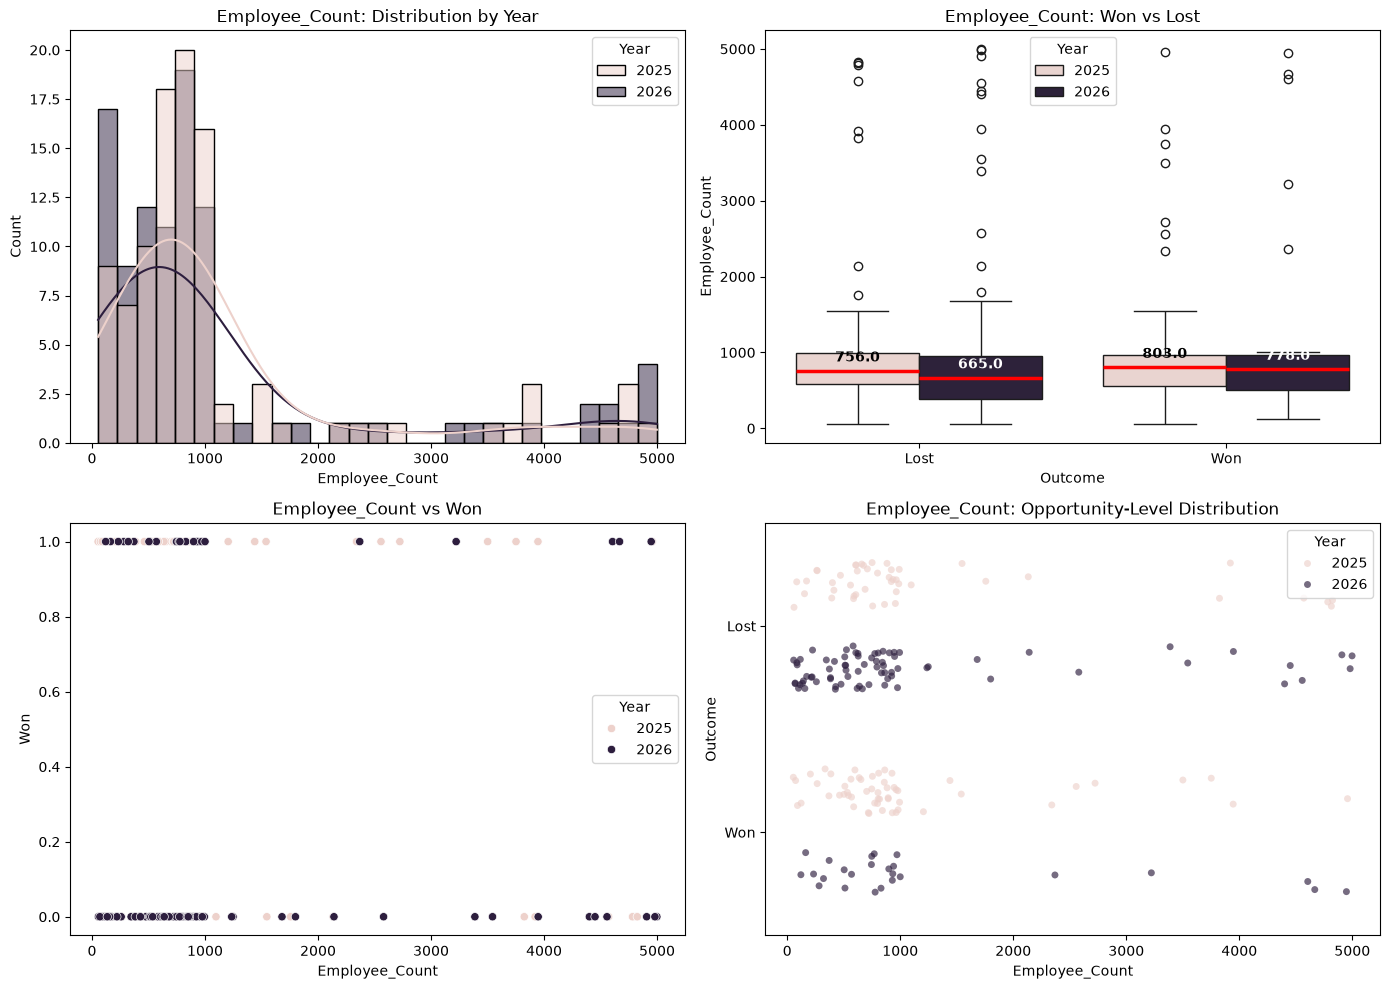

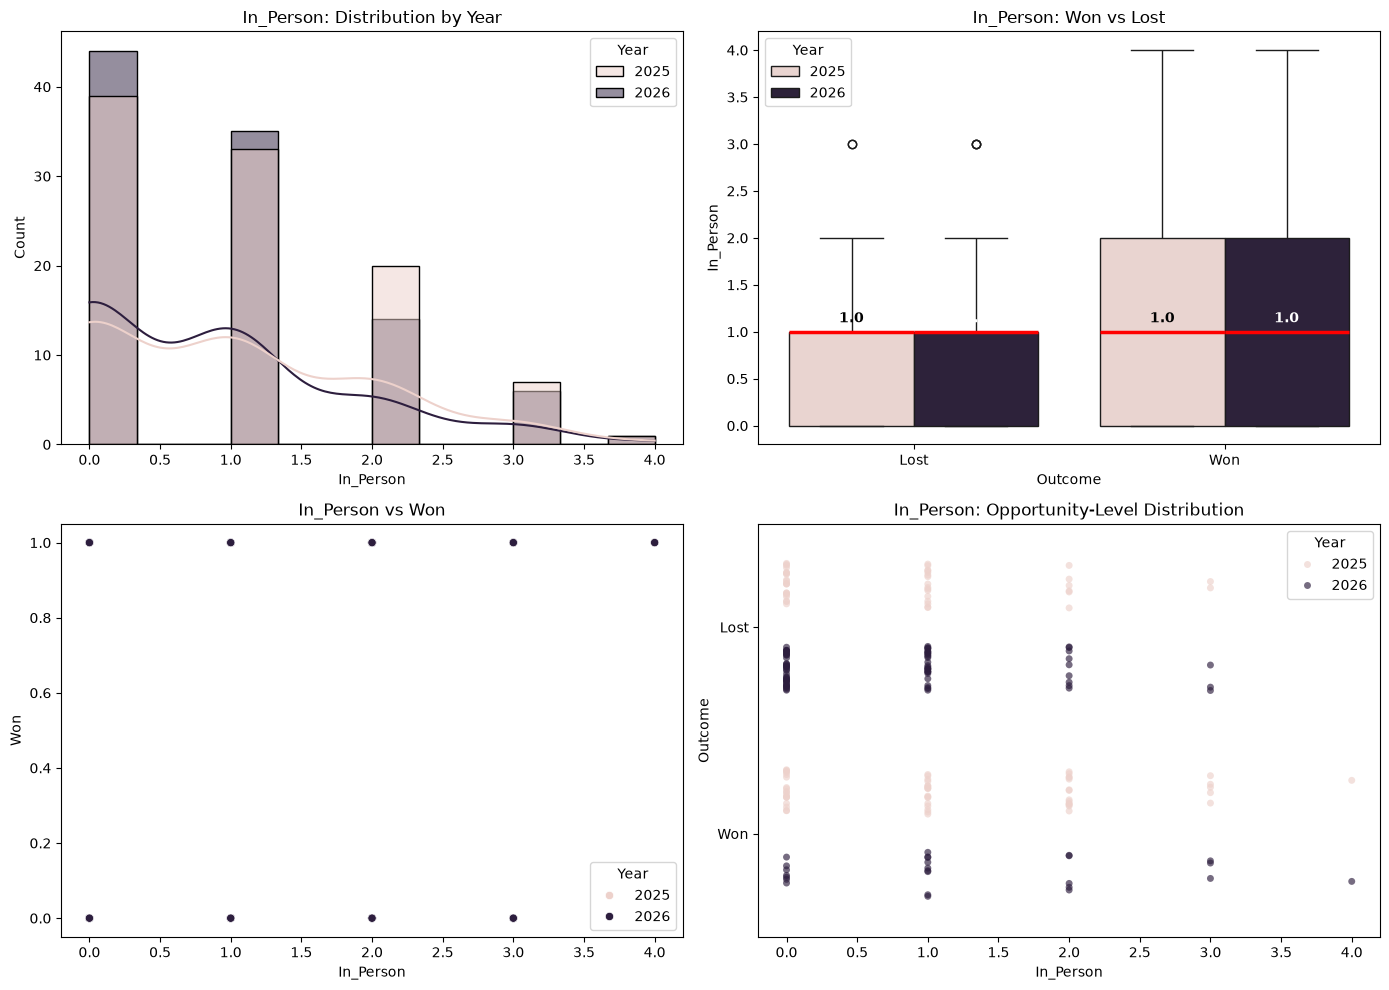

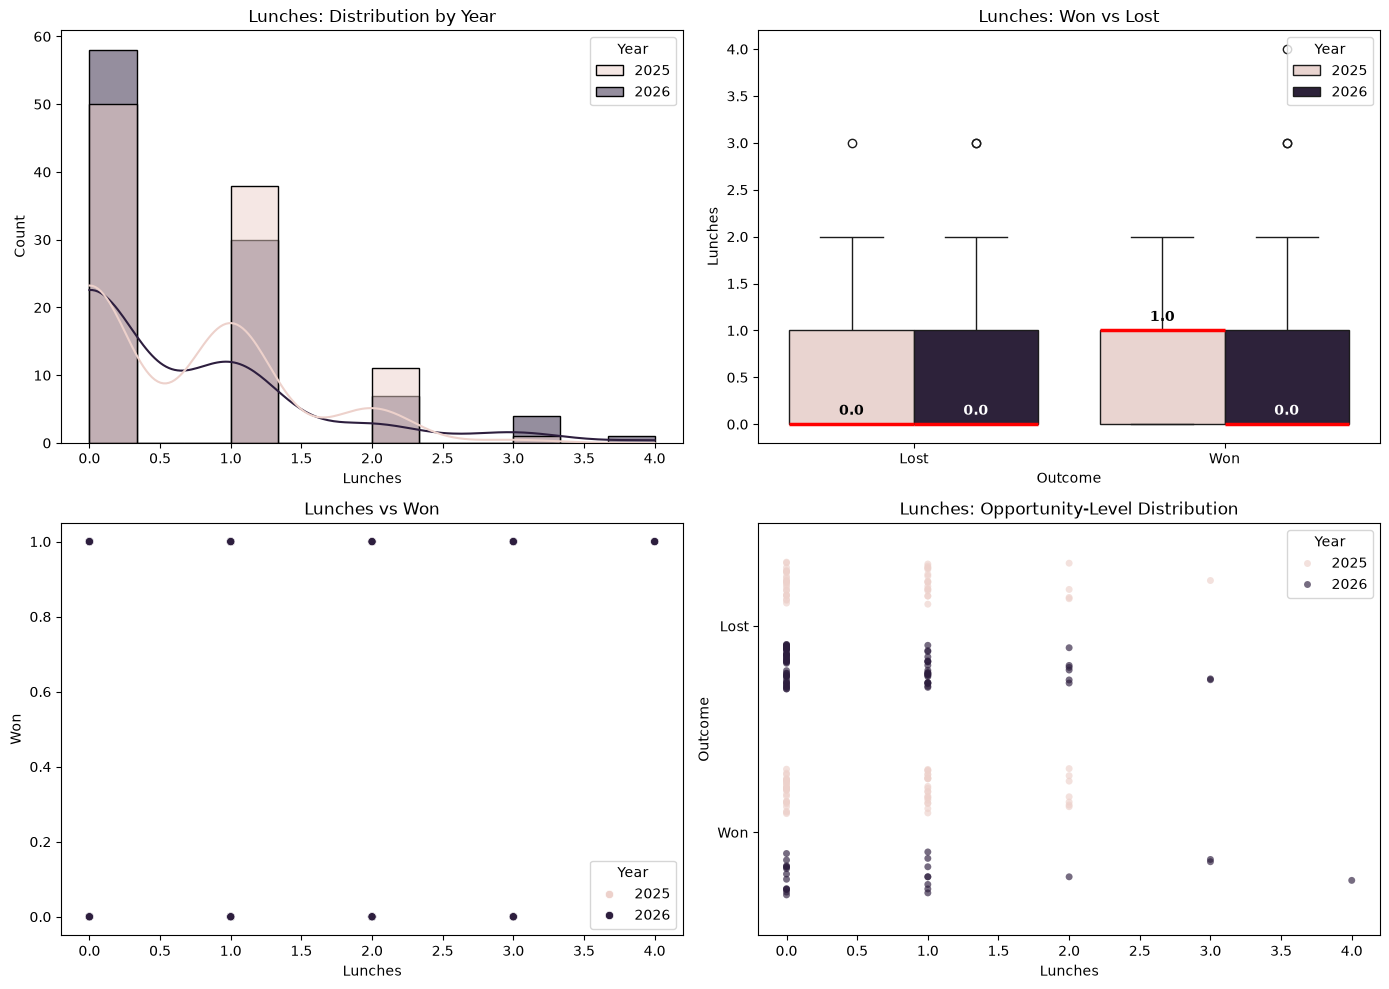

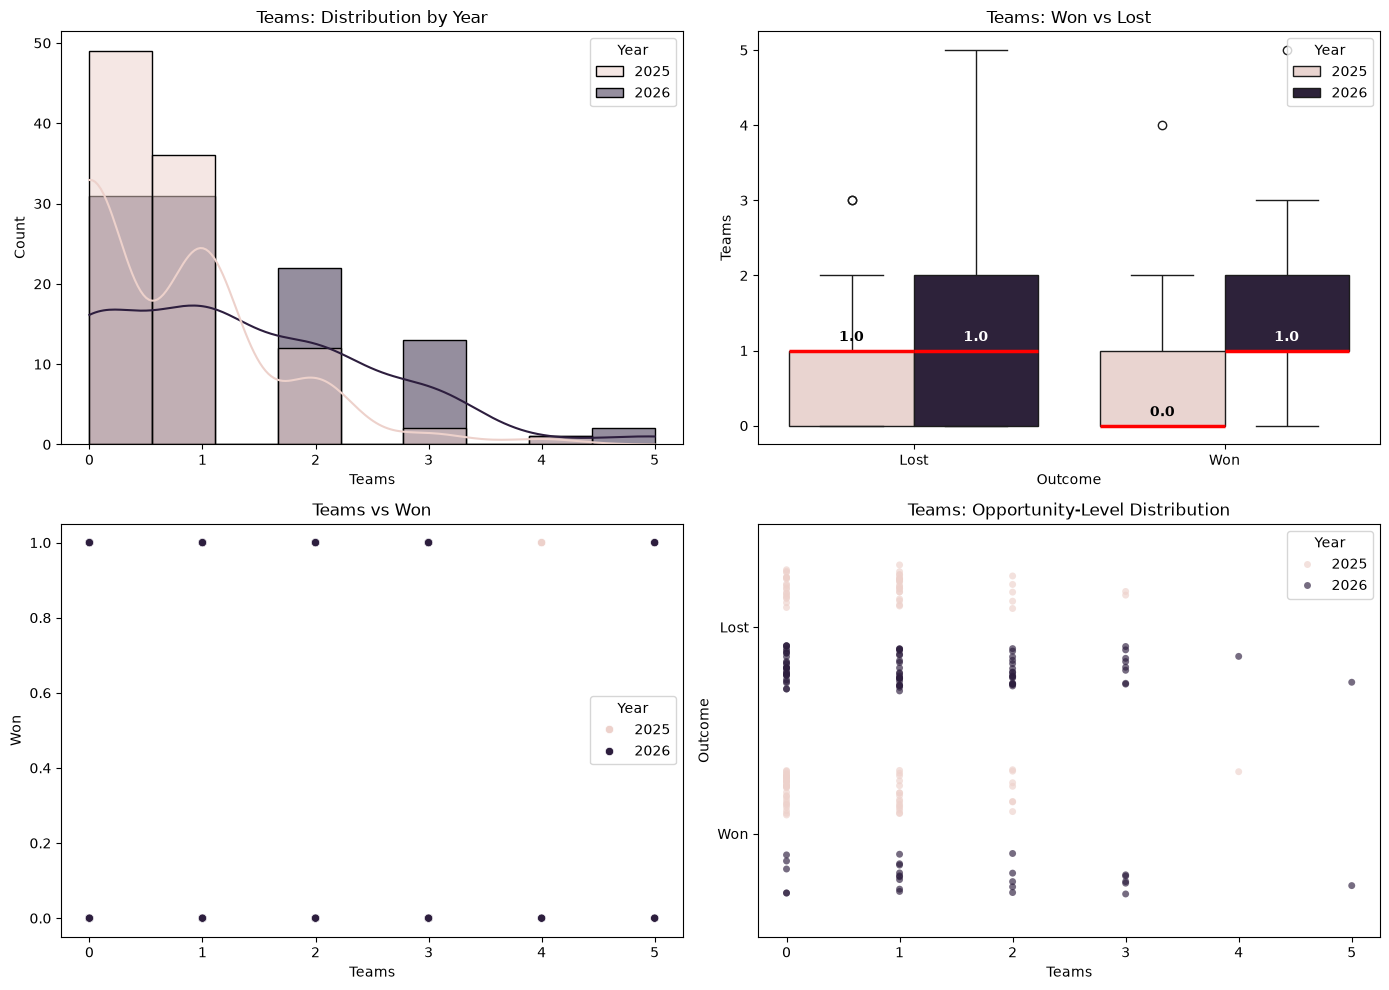

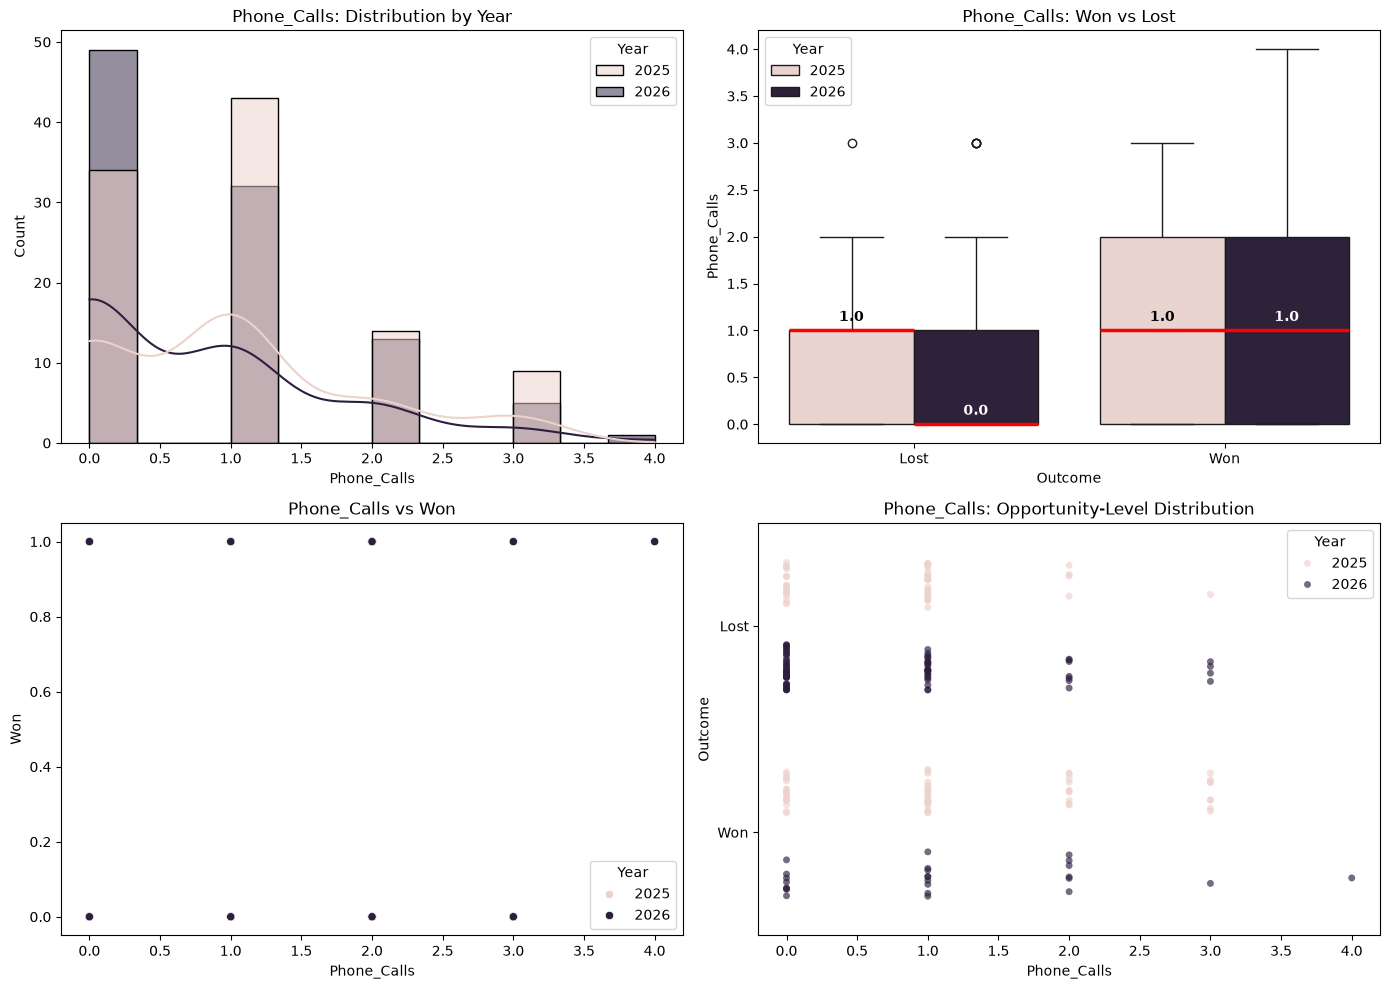

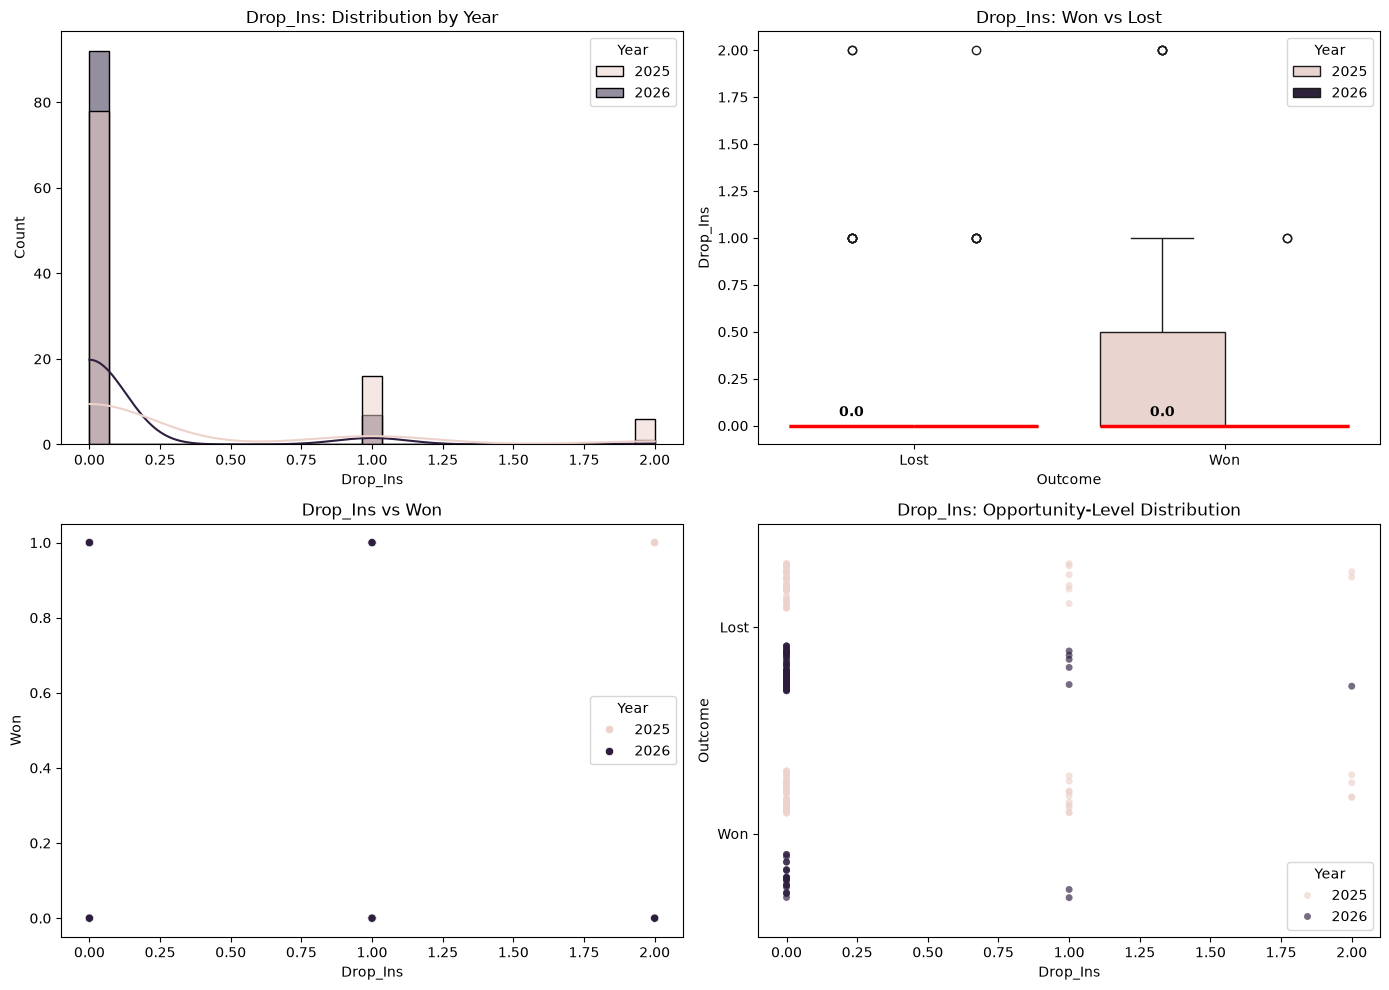

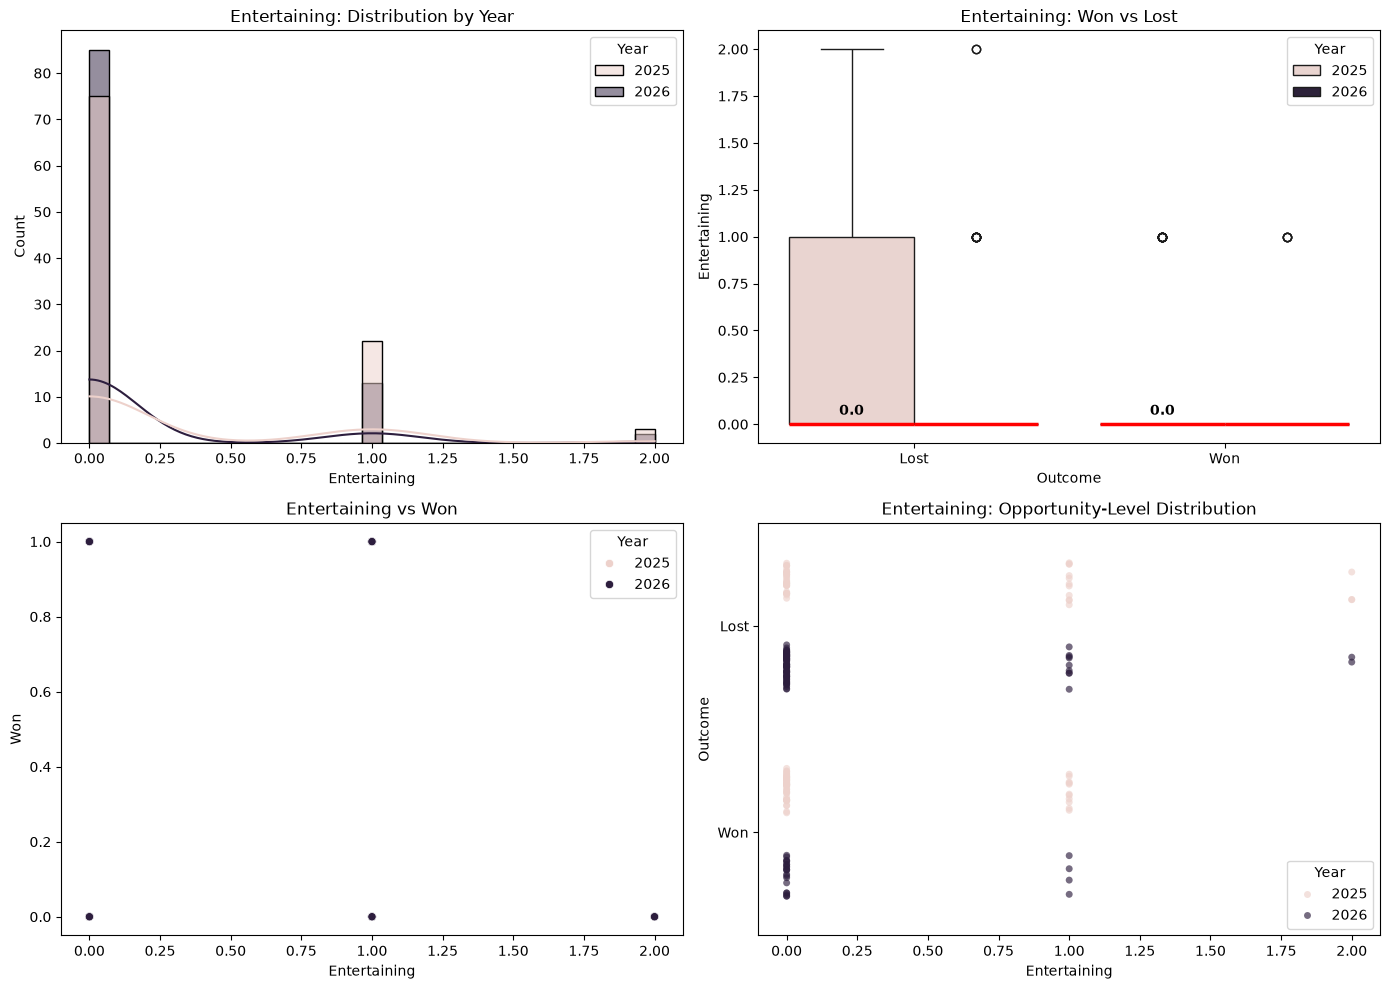

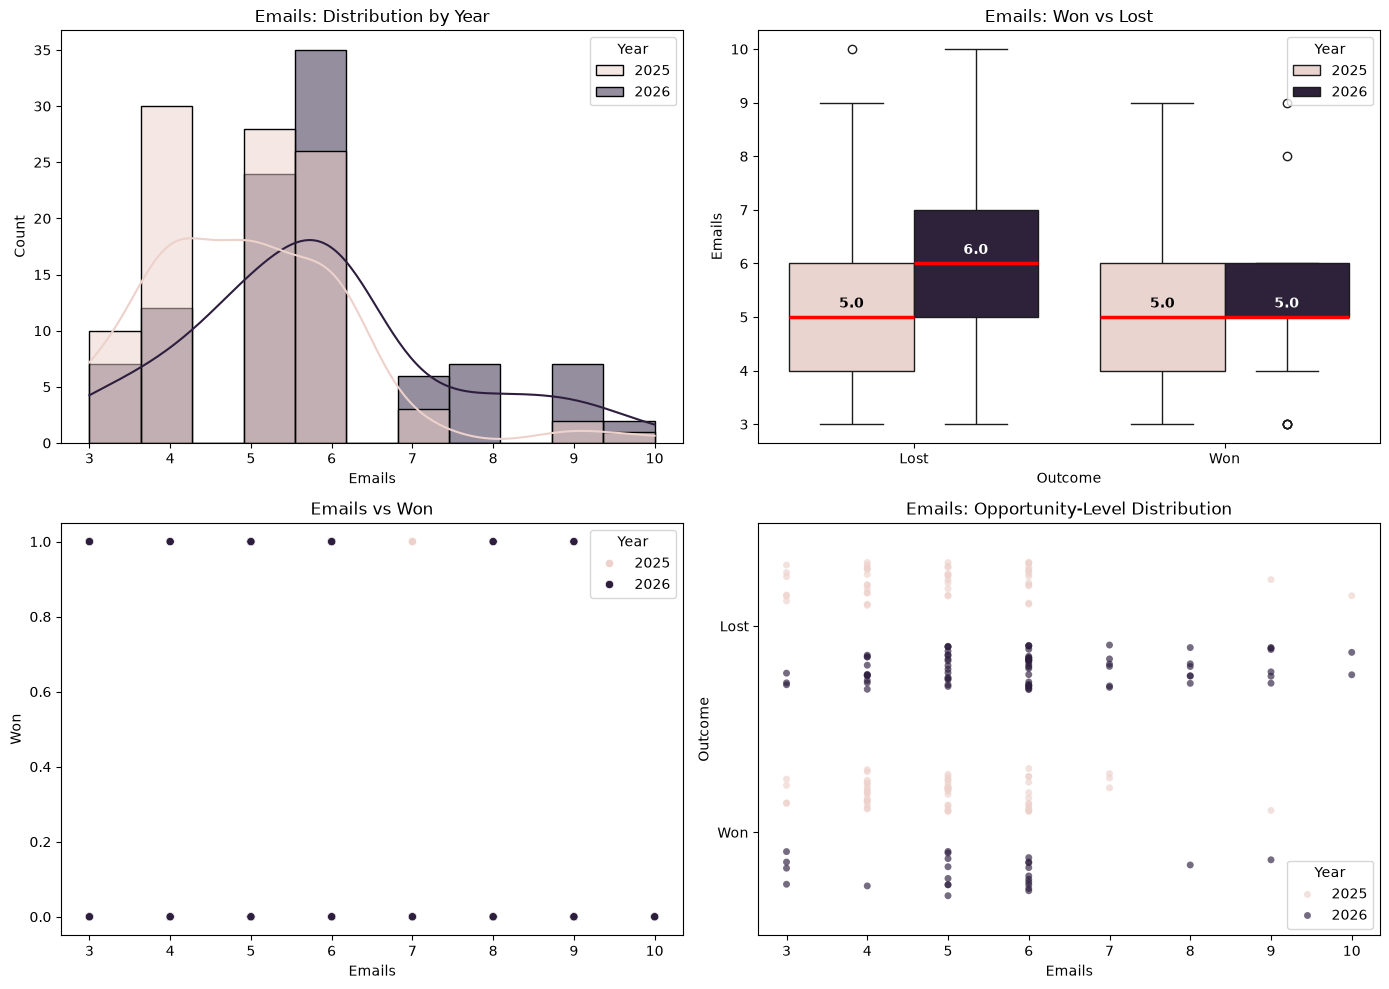

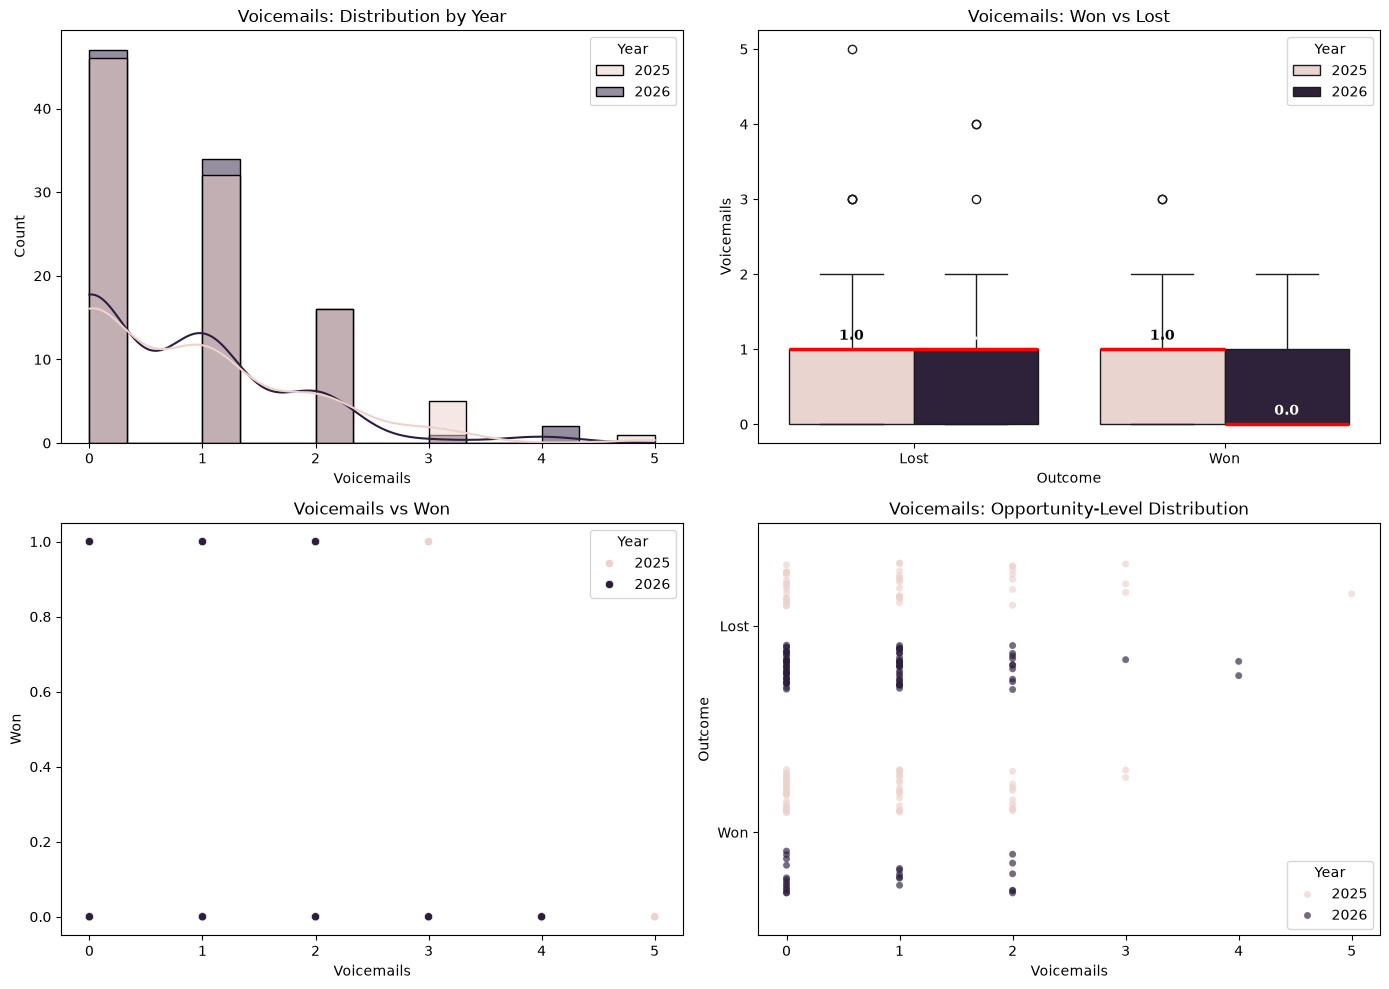

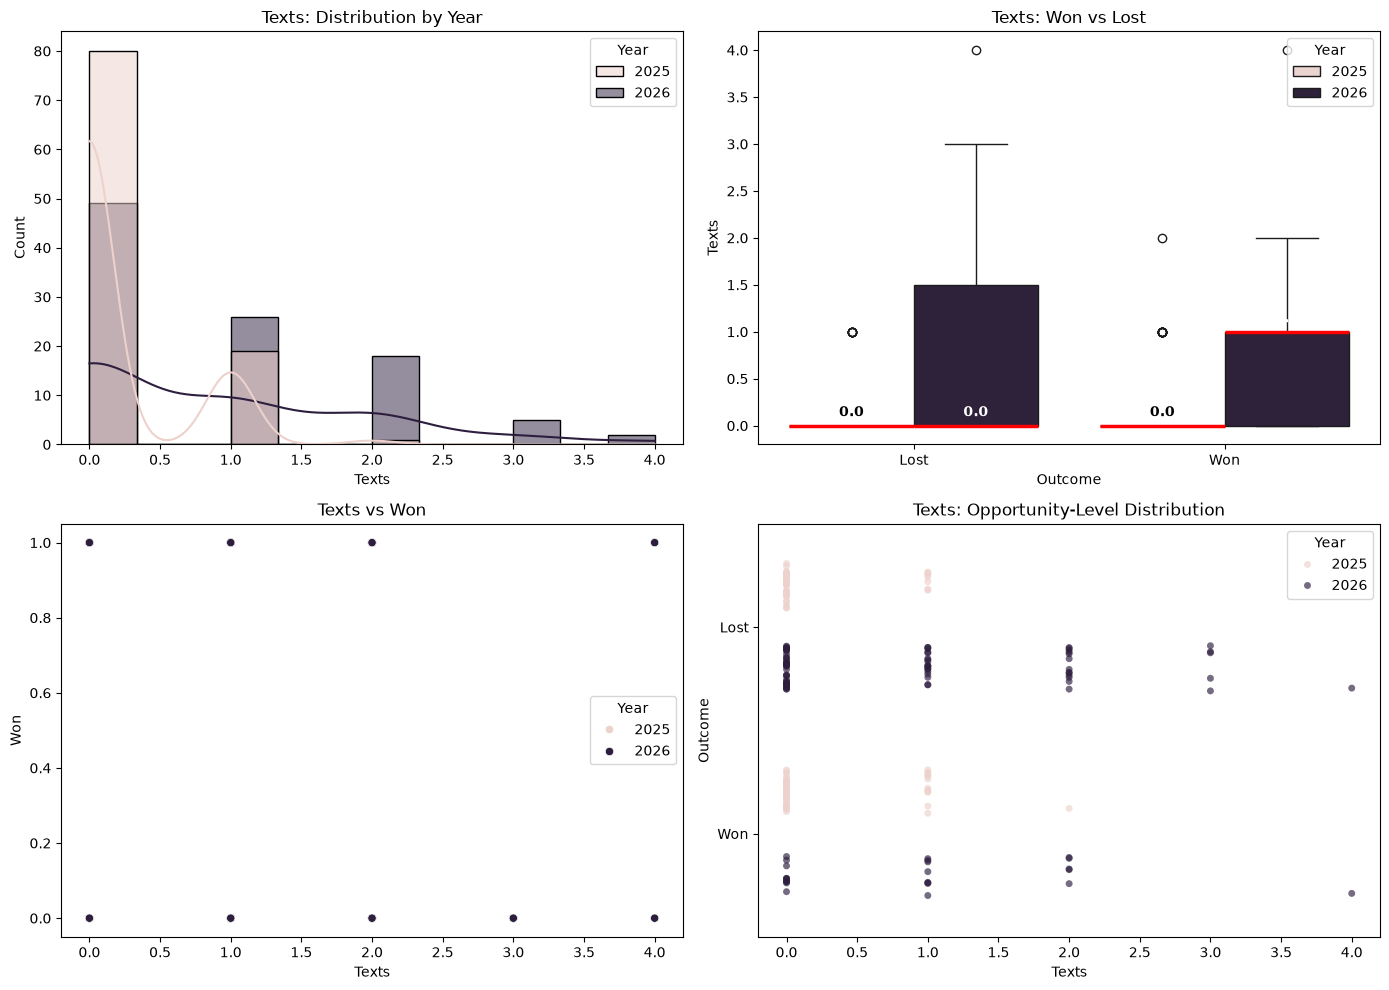

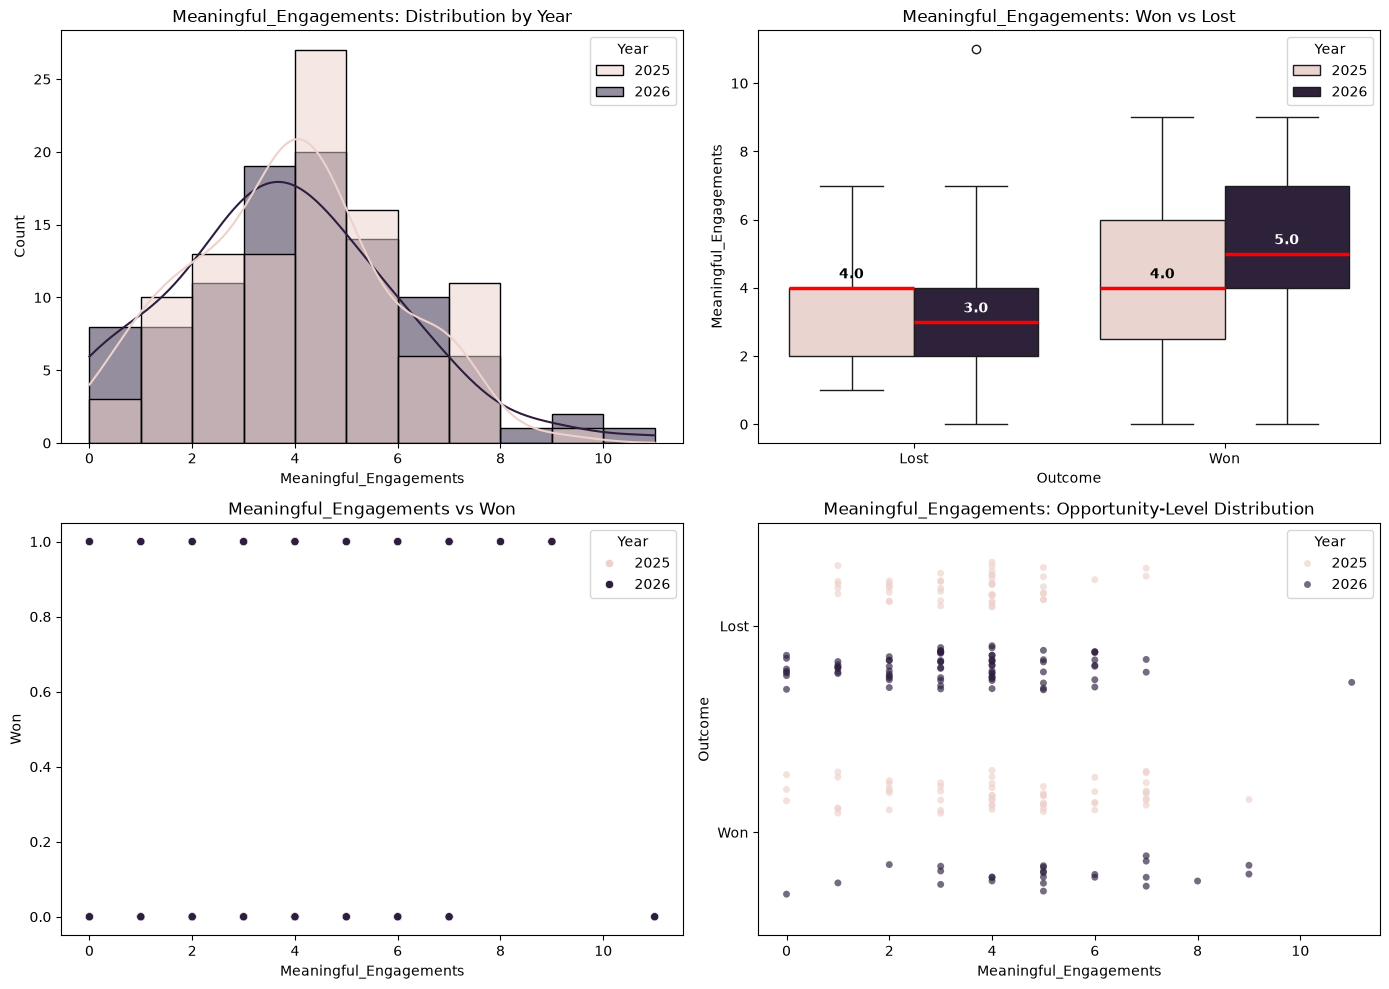

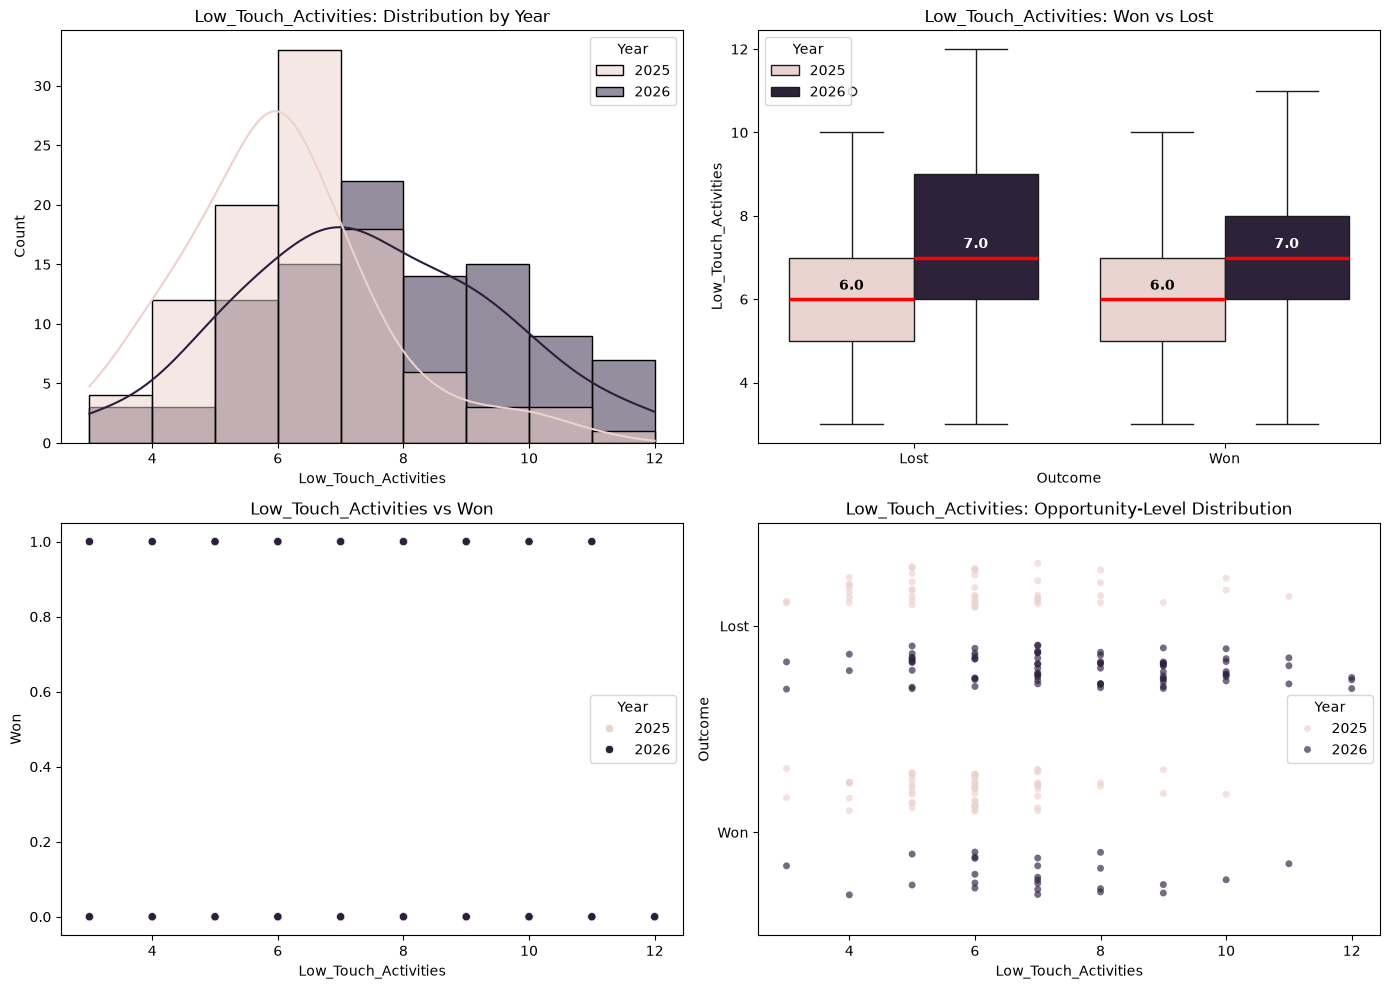

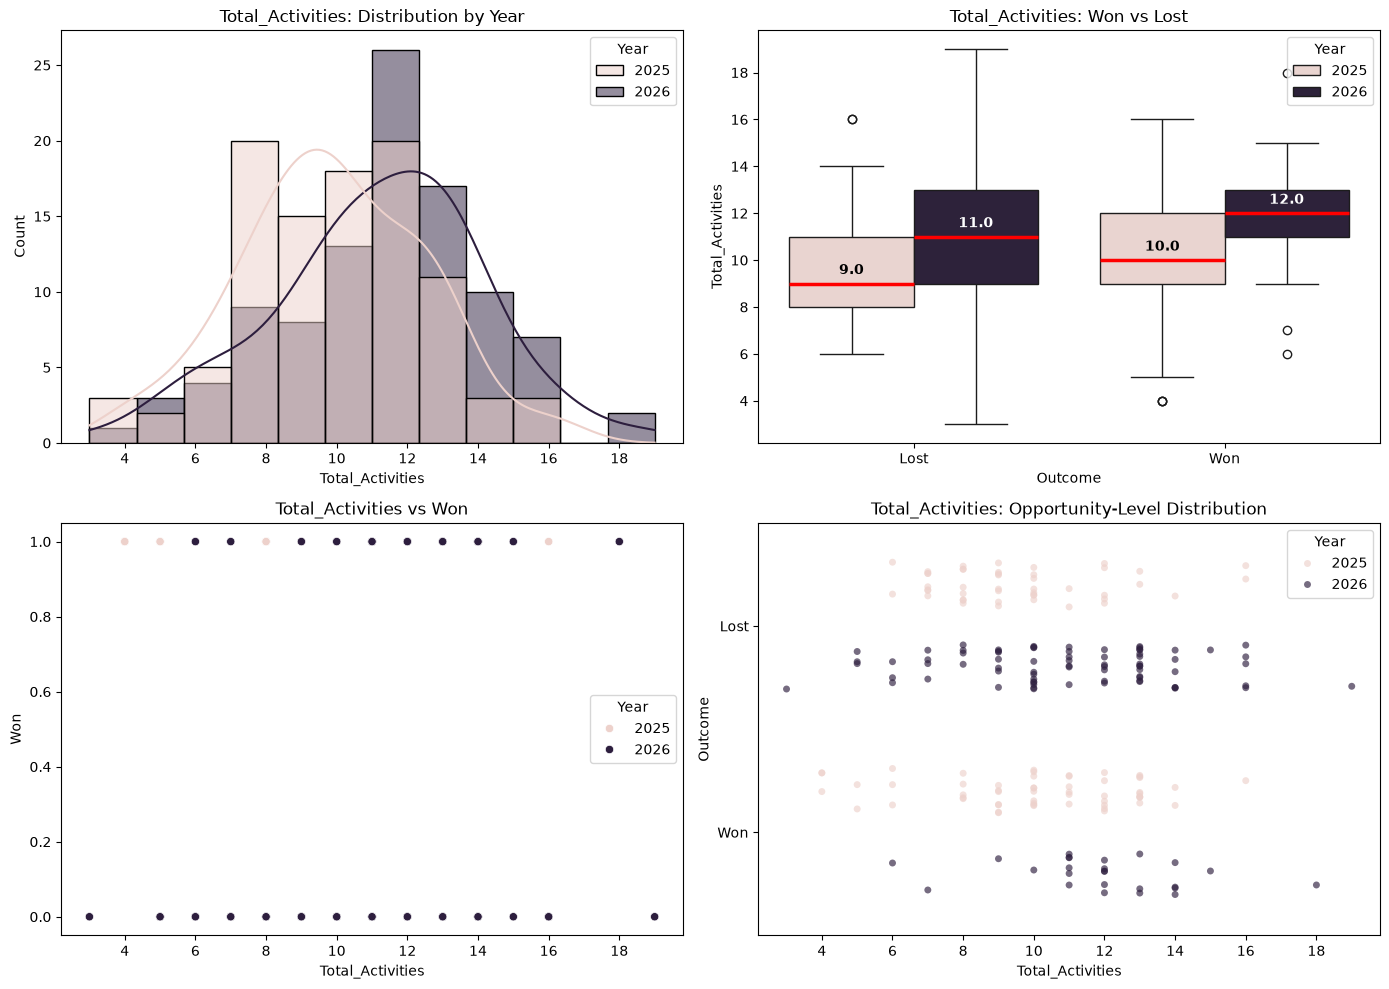

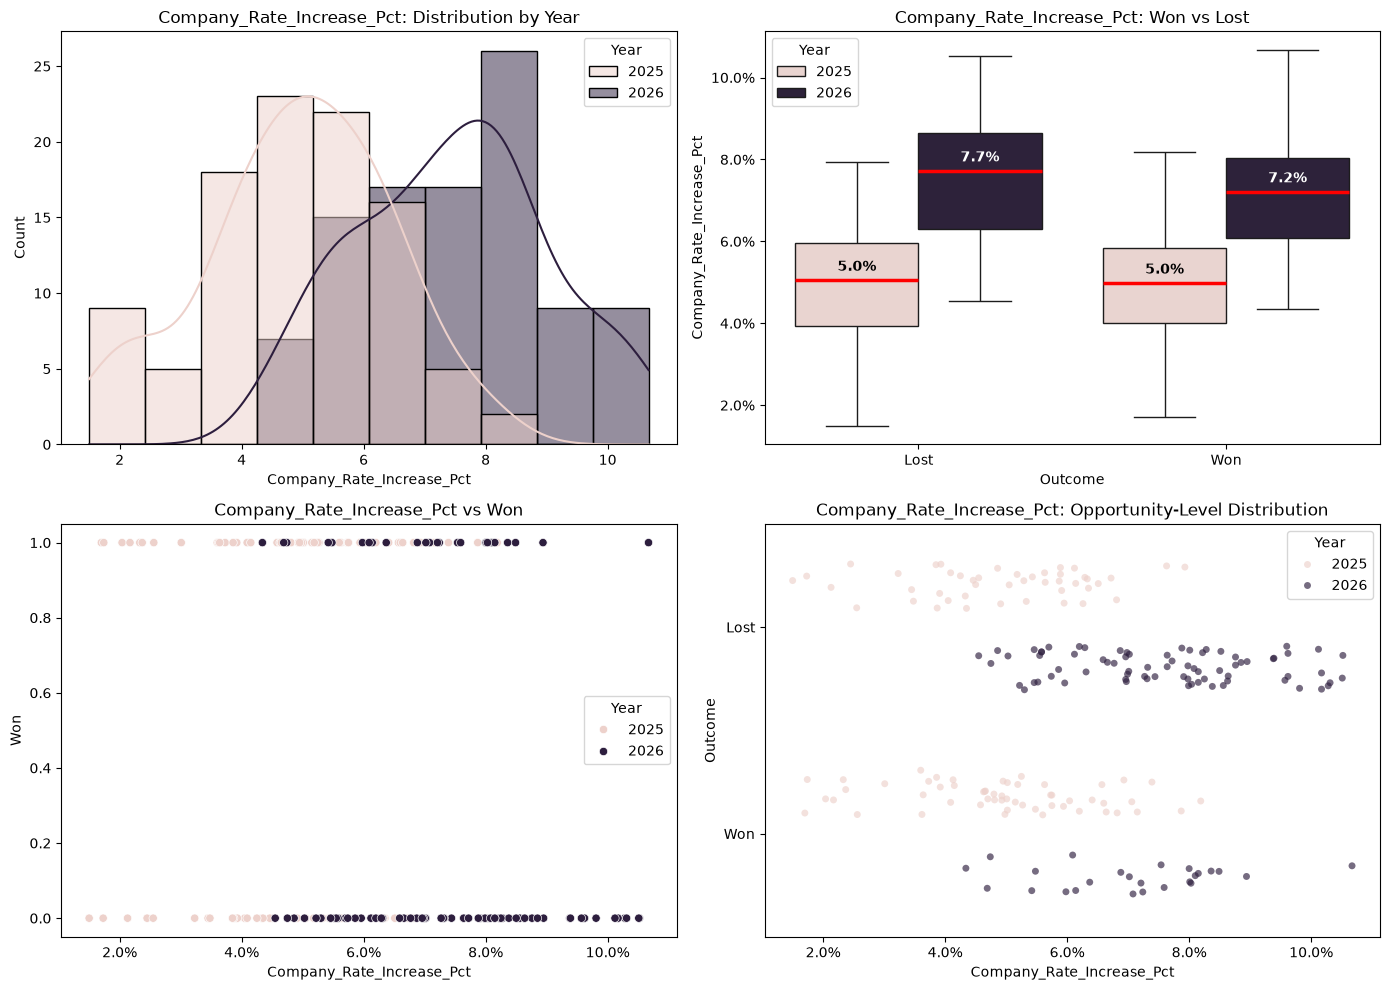

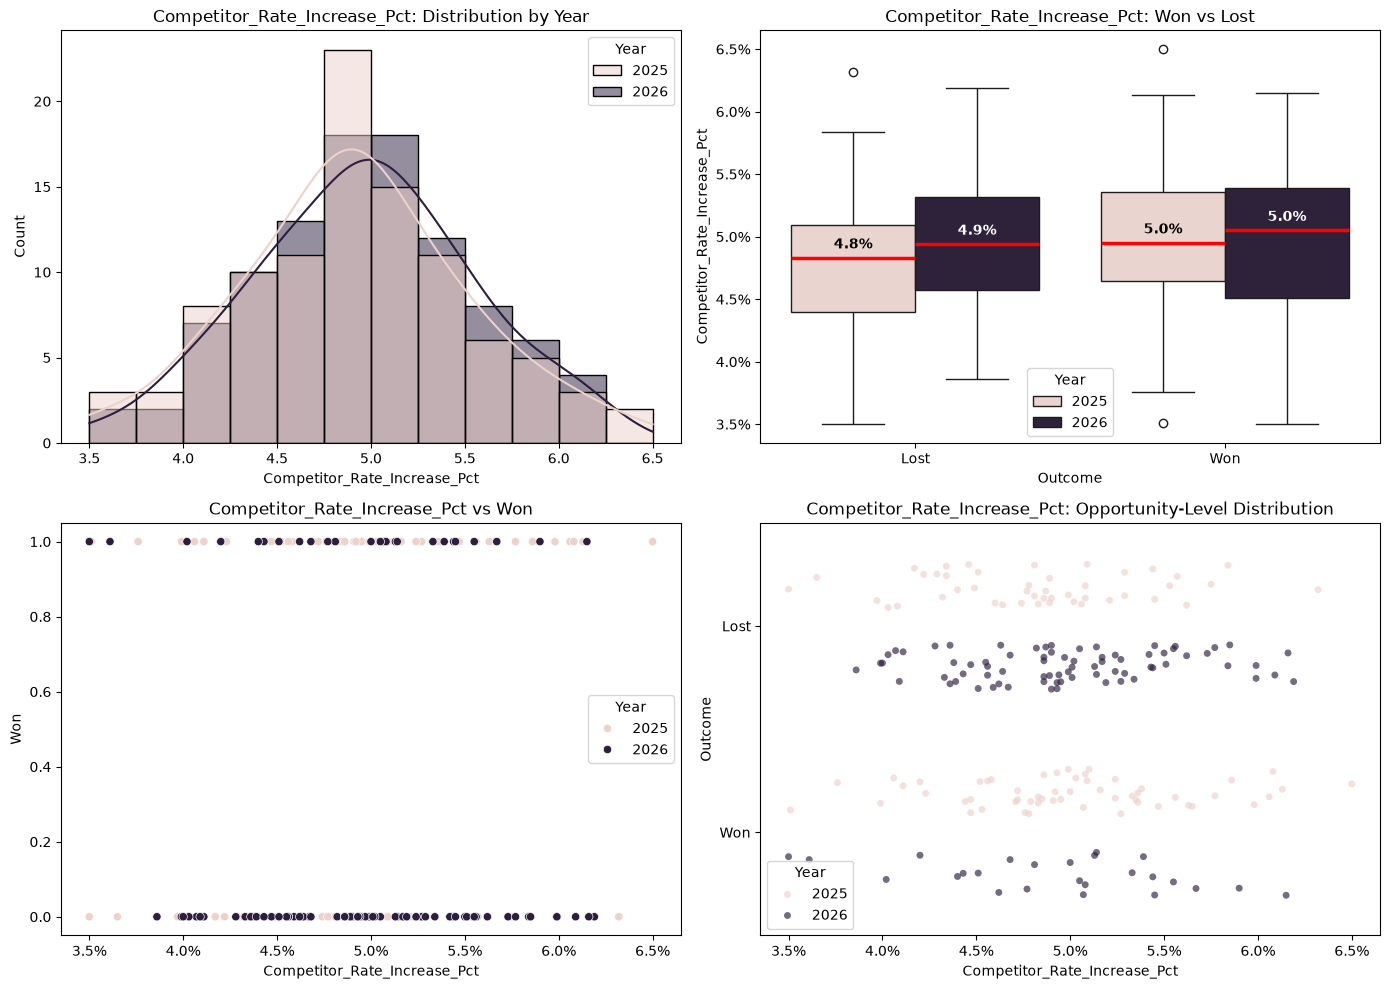

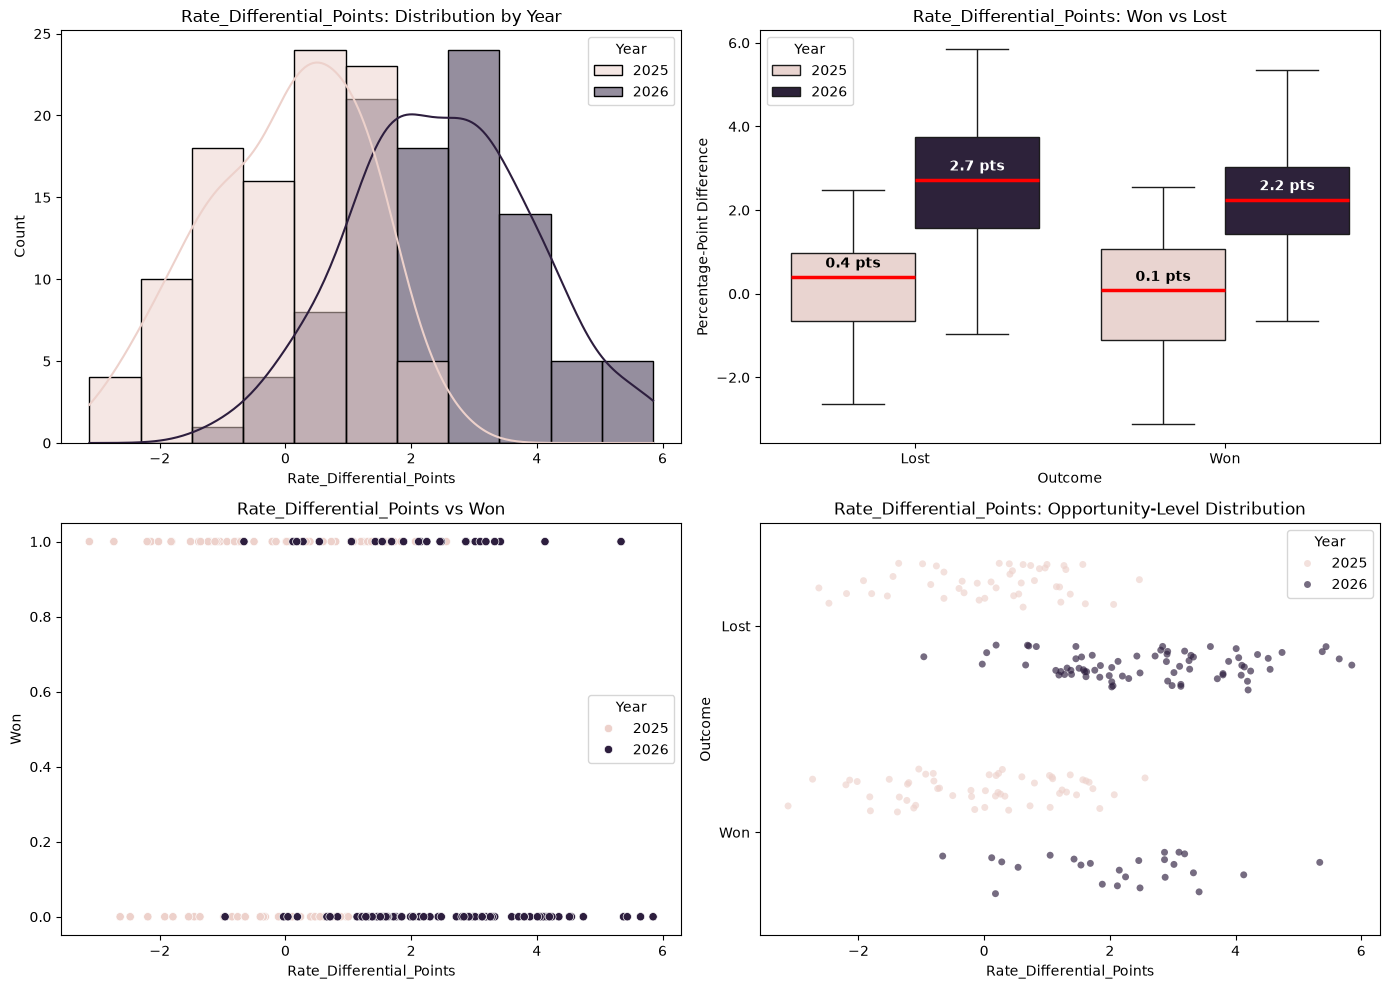

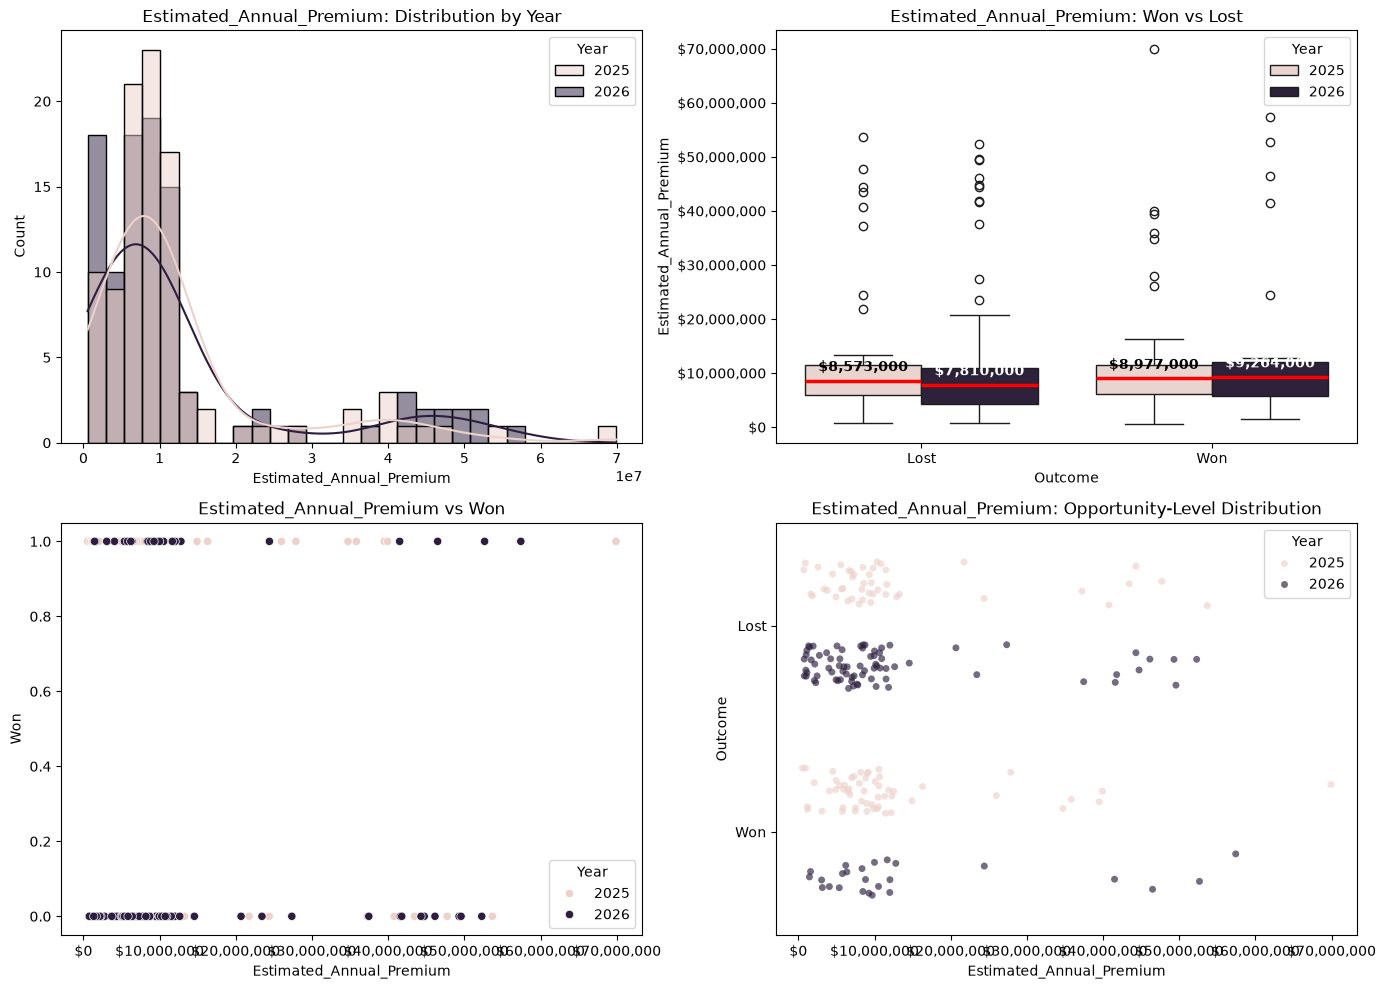

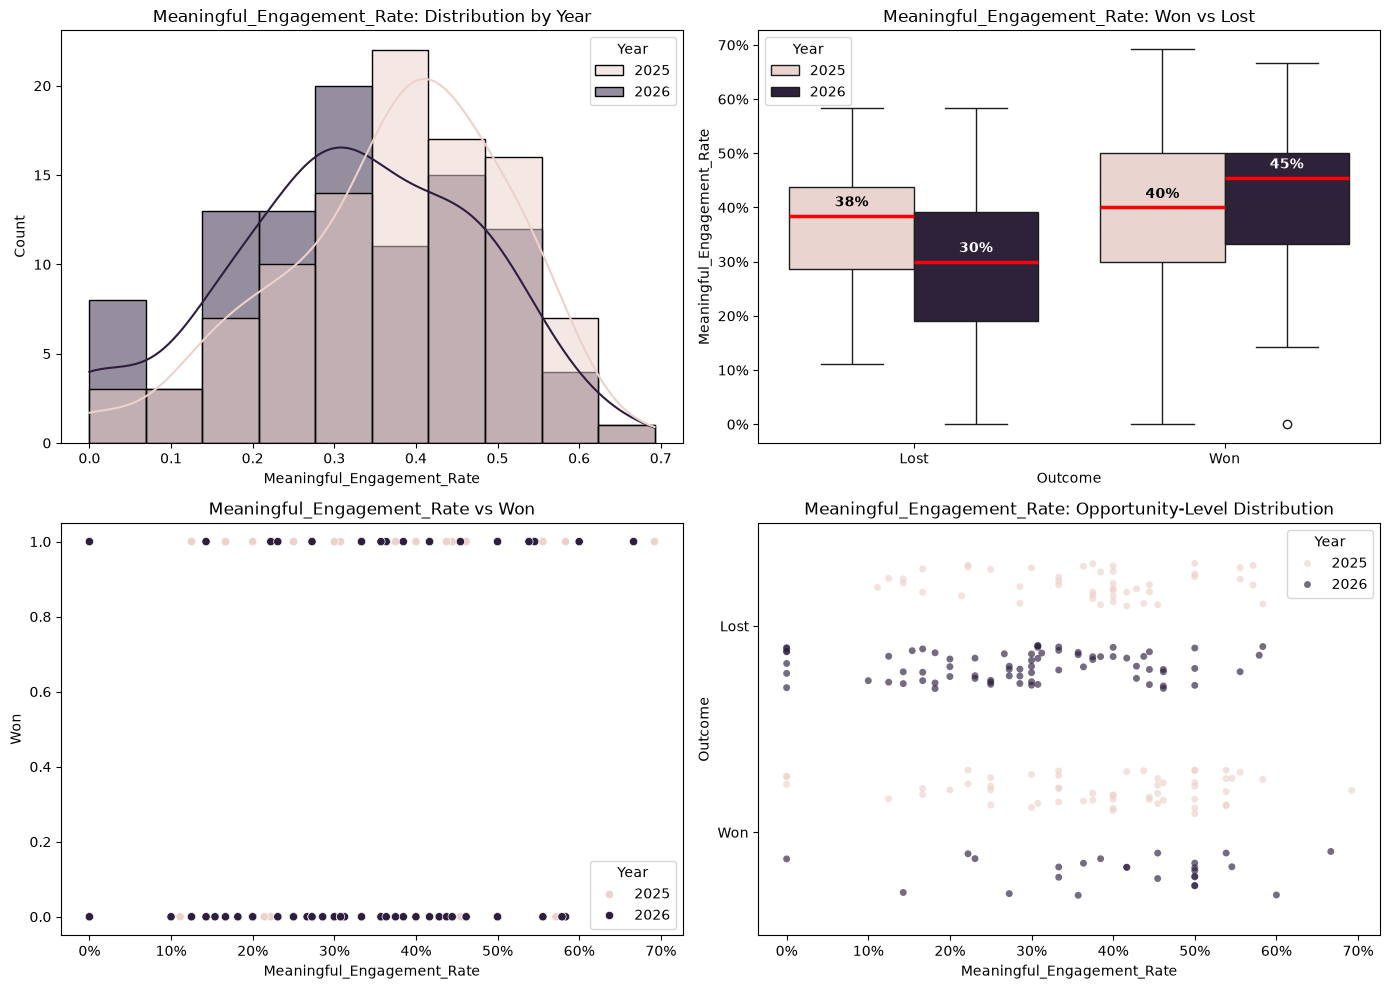

In [6]:
# ============================================================
# CONTINUOUS-MEASURE EDA
# ============================================================
# For each continuous measure, inspect:
# 1. Distribution by year
# 2. Won vs Lost distribution
# 3. Relationship with Won
# 4. Individual opportunity-level observations
#
# Formatting is based on the actual units of each variable.
# ============================================================

from matplotlib.ticker import (
    PercentFormatter,
    StrMethodFormatter
)


# ------------------------------------------------------------
# VARIABLE TYPES / DISPLAY FORMATS
# ------------------------------------------------------------

# Stored as decimal proportions from 0 to 1
proportion_vars = [
    "Meaningful_Engagement_Rate"
]

# Stored as percentage values already
percentage_vars = [
    "Company_Rate_Increase_Pct",
    "Competitor_Rate_Increase_Pct"
]

# Stored as percentage-point differences
percentage_point_vars = [
    "Rate_Differential_Points"
]

# Currency variables
currency_vars = [
    "Estimated_Annual_Premium"
]


# ------------------------------------------------------------
# MEDIAN LABEL FORMATTER
# ------------------------------------------------------------

def format_median(var, value):

    if var in proportion_vars:
        return f"{value:.0%}"

    elif var in percentage_vars:
        return f"{value:.1f}%"

    elif var in percentage_point_vars:
        return f"{value:.1f} pts"

    elif var in currency_vars:
        return f"${value:,.0f}"

    else:
        return f"{value:,.1f}"


# ============================================================
# RUN EDA
# ============================================================

for var in continuous_vars:

    fig, axes = plt.subplots(
        2, 2,
        figsize=(14, 10)
    )


    # --------------------------------------------------------
    # 1. DISTRIBUTION BY YEAR
    # --------------------------------------------------------

    sns.histplot(
        data=df,
        x=var,
        hue="Year",
        kde=True,
        ax=axes[0, 0]
    )

    axes[0, 0].set_title(
        f"{var}: Distribution by Year"
    )


    # --------------------------------------------------------
    # 2. WON VS LOST BOXPLOT
    # --------------------------------------------------------

    ax = axes[0, 1]

    sns.boxplot(
        data=df,
        x="Outcome",
        y=var,
        hue="Year",
        medianprops={
            "color": "red",
            "linewidth": 2.5
        },
        ax=ax
    )

    ax.set_title(
        f"{var}: Won vs Lost"
    )


    # --------------------------------------------------------
    # FORMAT BOXPLOT Y-AXIS CORRECTLY
    # --------------------------------------------------------

    if var in proportion_vars:

        # Example:
        # 0.30 displays as 30%
        ax.yaxis.set_major_formatter(
            PercentFormatter(
                xmax=1,
                decimals=0
            )
        )

    elif var in percentage_vars:

        # Example:
        # 7.5 displays as 7.5%
        ax.yaxis.set_major_formatter(
            StrMethodFormatter(
                "{x:.1f}%"
            )
        )

    elif var in percentage_point_vars:

        # Example:
        # 2.5 displays as 2.5
        # Axis label explains these are points
        ax.yaxis.set_major_formatter(
            StrMethodFormatter(
                "{x:.1f}"
            )
        )

        ax.set_ylabel(
            "Percentage-Point Difference"
        )

    elif var in currency_vars:

        ax.yaxis.set_major_formatter(
            StrMethodFormatter(
                "${x:,.0f}"
            )
        )


    # --------------------------------------------------------
    # CALCULATE MEDIANS
    # --------------------------------------------------------

    median_data = (
        df.groupby(
            ["Outcome", "Year"],
            observed=True
        )[var]
        .median()
    )


    # Box positions created by hue
    offsets = {
        2025: -0.20,
        2026: 0.20
    }


    # Get actual displayed Outcome order
    outcomes = [
        tick.get_text()
        for tick in ax.get_xticklabels()
    ]


    # --------------------------------------------------------
    # ADD MEDIAN VALUE TO EACH BOX
    # --------------------------------------------------------

    y_min, y_max = ax.get_ylim()

    # Offset labels relative to each variable's scale
    label_offset = (
        y_max - y_min
    ) * 0.015


    for x_position, outcome in enumerate(outcomes):

        for year in [2025, 2026]:

            # Skip combinations that do not exist
            if (
                outcome,
                year
            ) not in median_data.index:
                continue

            median_value = median_data.loc[
                outcome,
                year
            ]


            # 2026 boxes are dark
            label_color = (
                "white"
                if year == 2026
                else "black"
            )


            ax.text(
                x_position + offsets[year],
                median_value + label_offset,
                format_median(
                    var,
                    median_value
                ),
                ha="center",
                va="bottom",
                fontweight="bold",
                color=label_color
            )


    # --------------------------------------------------------
    # 3. RELATIONSHIP WITH WON
    # --------------------------------------------------------

    sns.scatterplot(
        data=df,
        x=var,
        y="Won",
        hue="Year",
        ax=axes[1, 0]
    )

    axes[1, 0].set_title(
        f"{var} vs Won"
    )


    # Format scatterplot X-axis correctly
    if var in proportion_vars:

        axes[1, 0].xaxis.set_major_formatter(
            PercentFormatter(
                xmax=1,
                decimals=0
            )
        )

    elif var in percentage_vars:

        axes[1, 0].xaxis.set_major_formatter(
            StrMethodFormatter(
                "{x:.1f}%"
            )
        )

    elif var in currency_vars:

        axes[1, 0].xaxis.set_major_formatter(
            StrMethodFormatter(
                "${x:,.0f}"
            )
        )


    # --------------------------------------------------------
    # 4. OPPORTUNITY-LEVEL DISTRIBUTION
    # --------------------------------------------------------

    sns.stripplot(
        data=df,
        x=var,
        y="Outcome",
        hue="Year",
        dodge=True,
        jitter=0.22,
        alpha=0.65,
        ax=axes[1, 1]
    )

    axes[1, 1].set_title(
        f"{var}: Opportunity-Level Distribution"
    )


    # Format stripplot X-axis correctly
    if var in proportion_vars:

        axes[1, 1].xaxis.set_major_formatter(
            PercentFormatter(
                xmax=1,
                decimals=0
            )
        )

    elif var in percentage_vars:

        axes[1, 1].xaxis.set_major_formatter(
            StrMethodFormatter(
                "{x:.1f}%"
            )
        )

    elif var in currency_vars:

        axes[1, 1].xaxis.set_major_formatter(
            StrMethodFormatter(
                "${x:,.0f}"
            )
        )


    # --------------------------------------------------------
    # FINISH FIGURE
    # --------------------------------------------------------

    plt.tight_layout()
    plt.show()

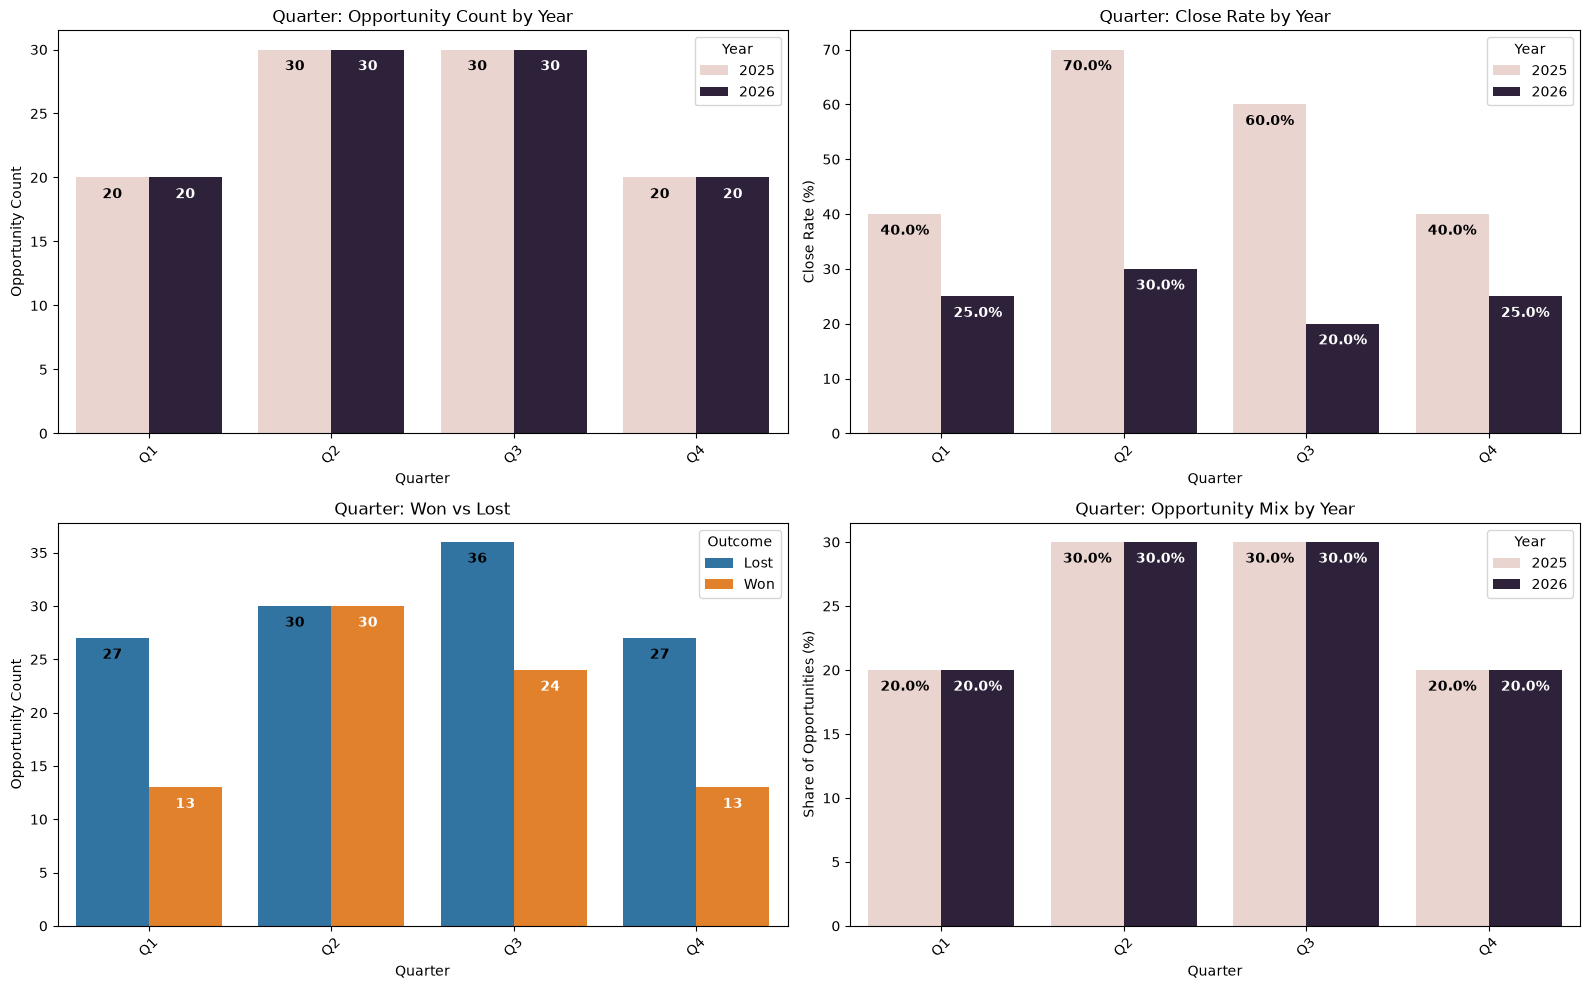

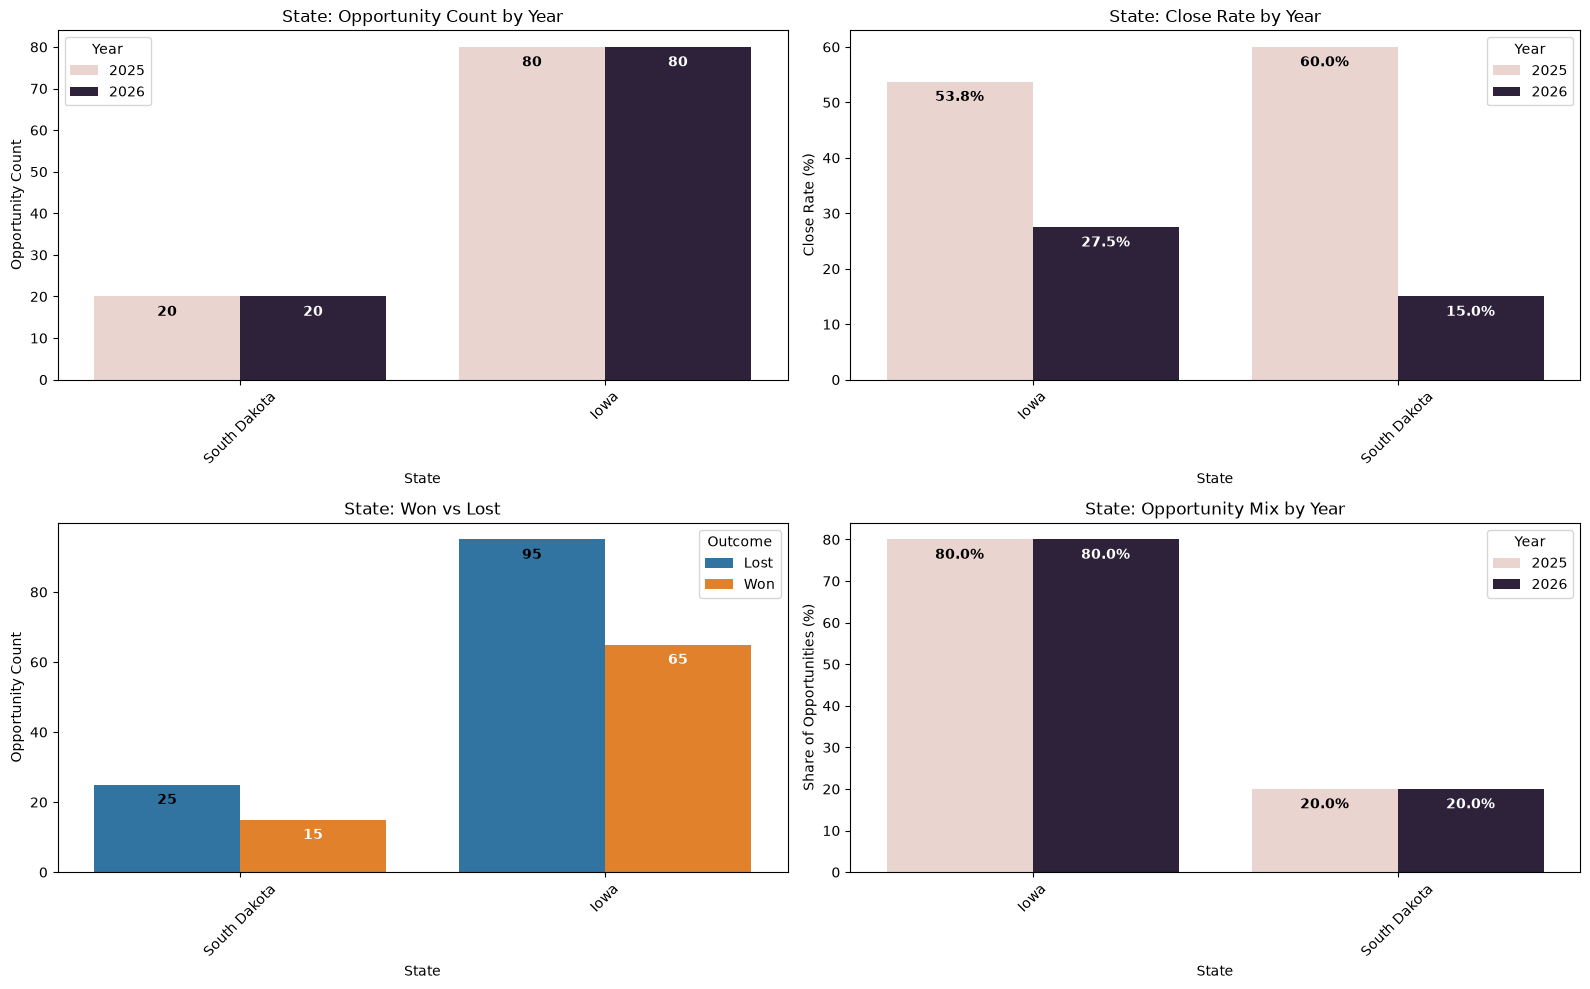

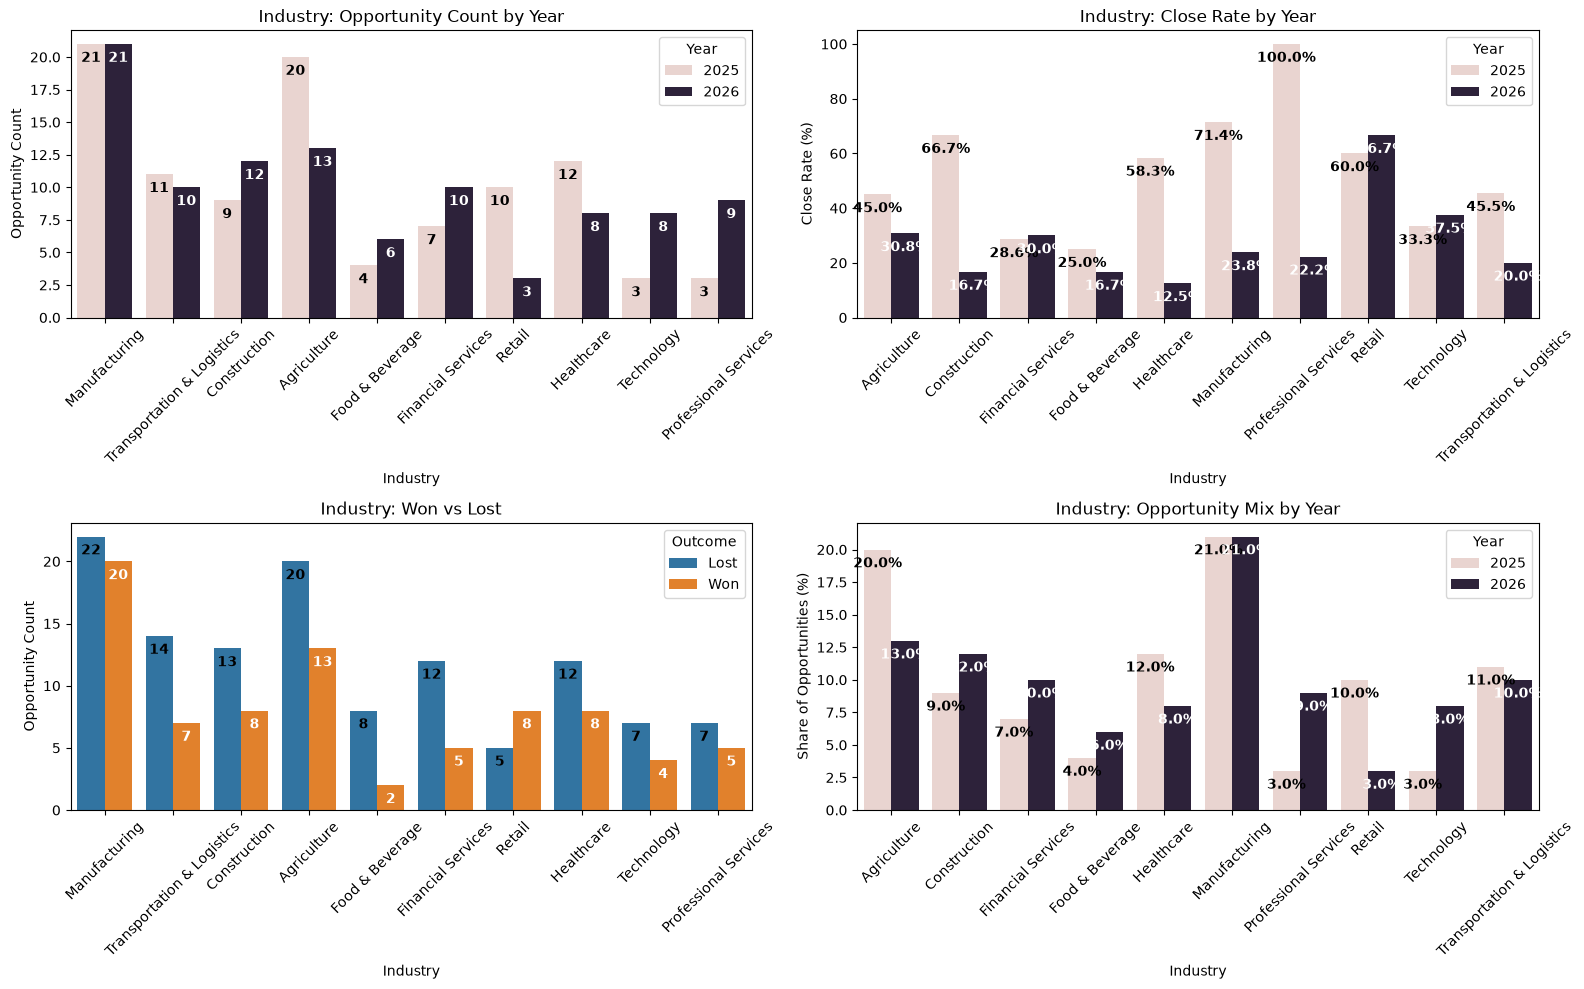

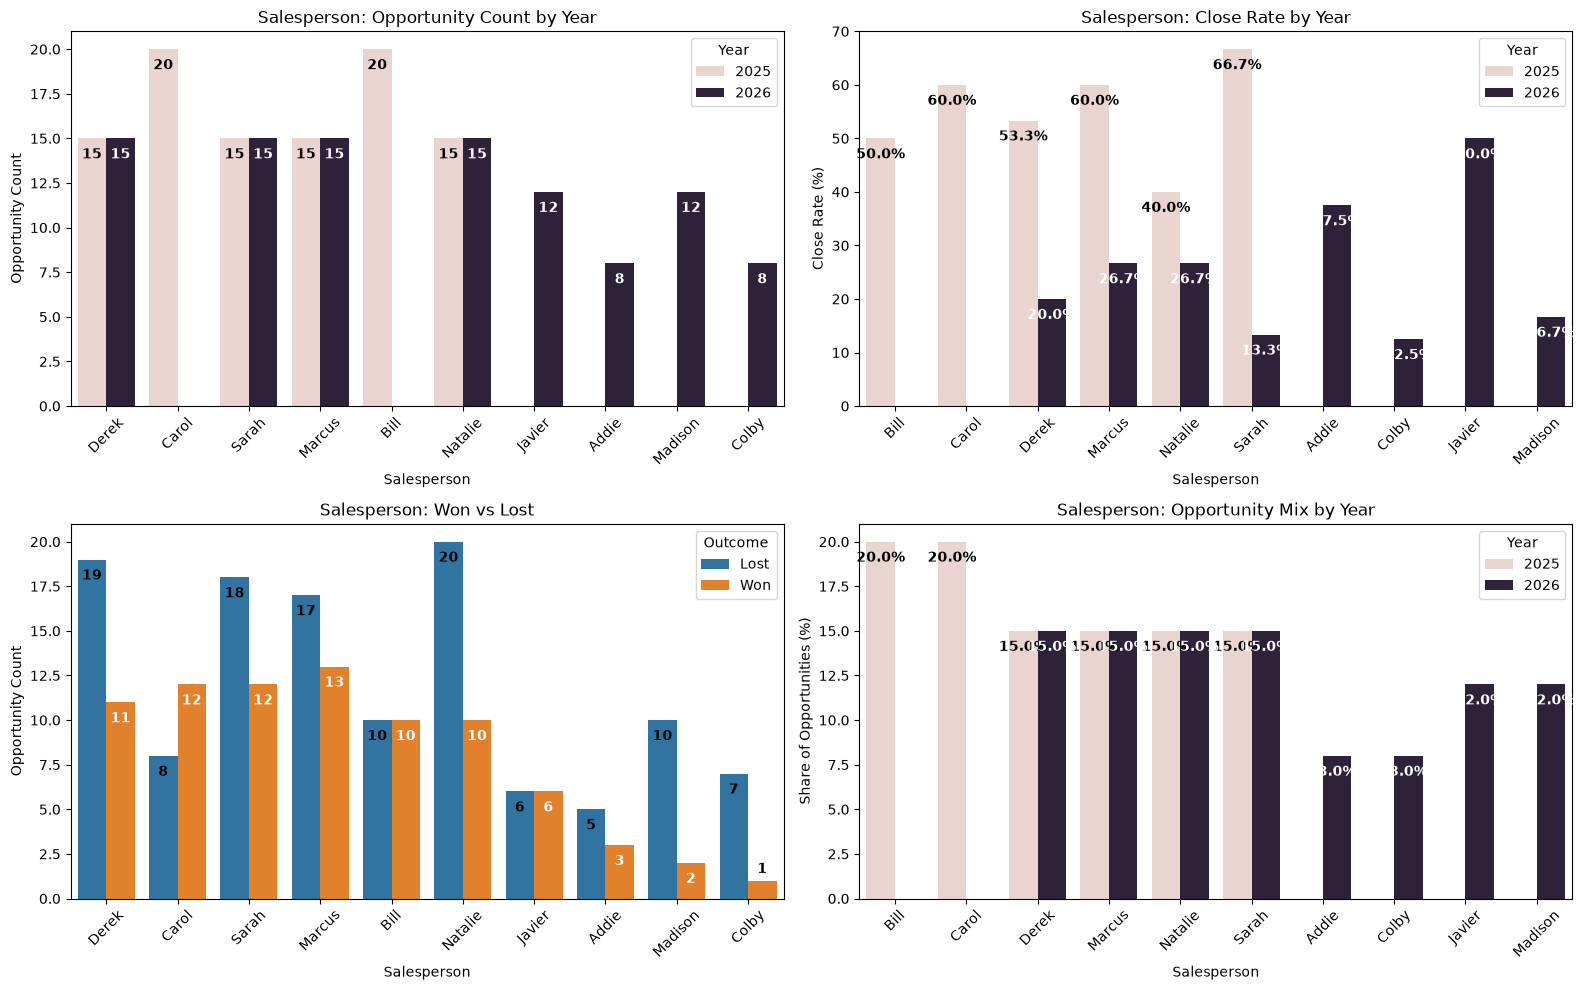

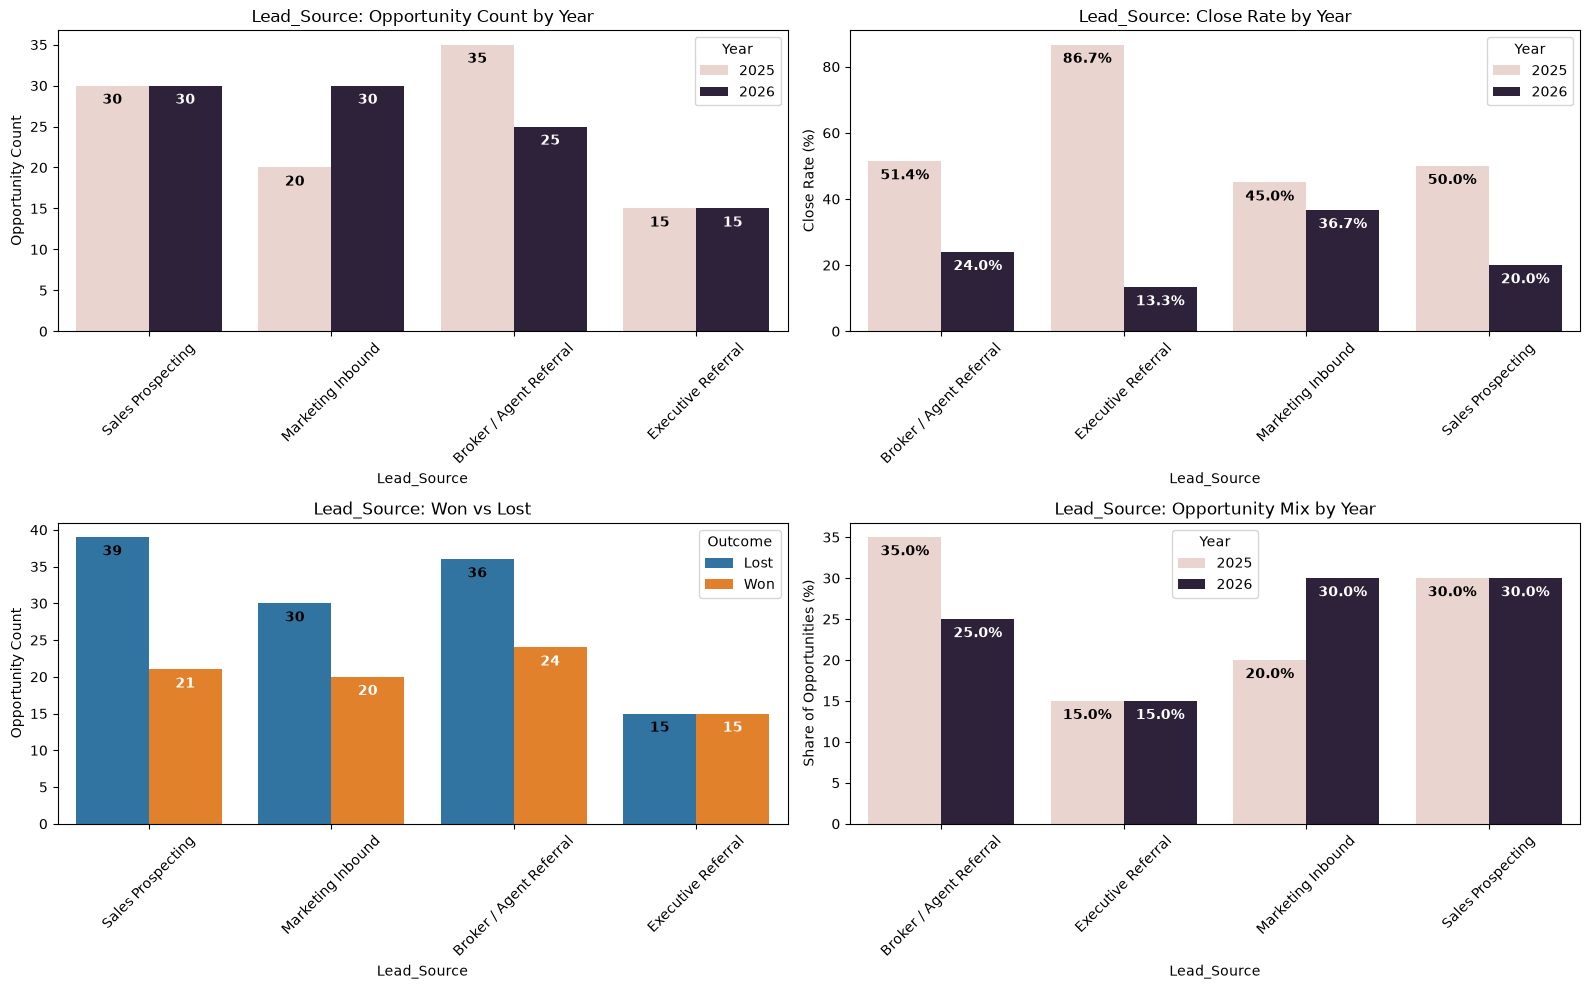

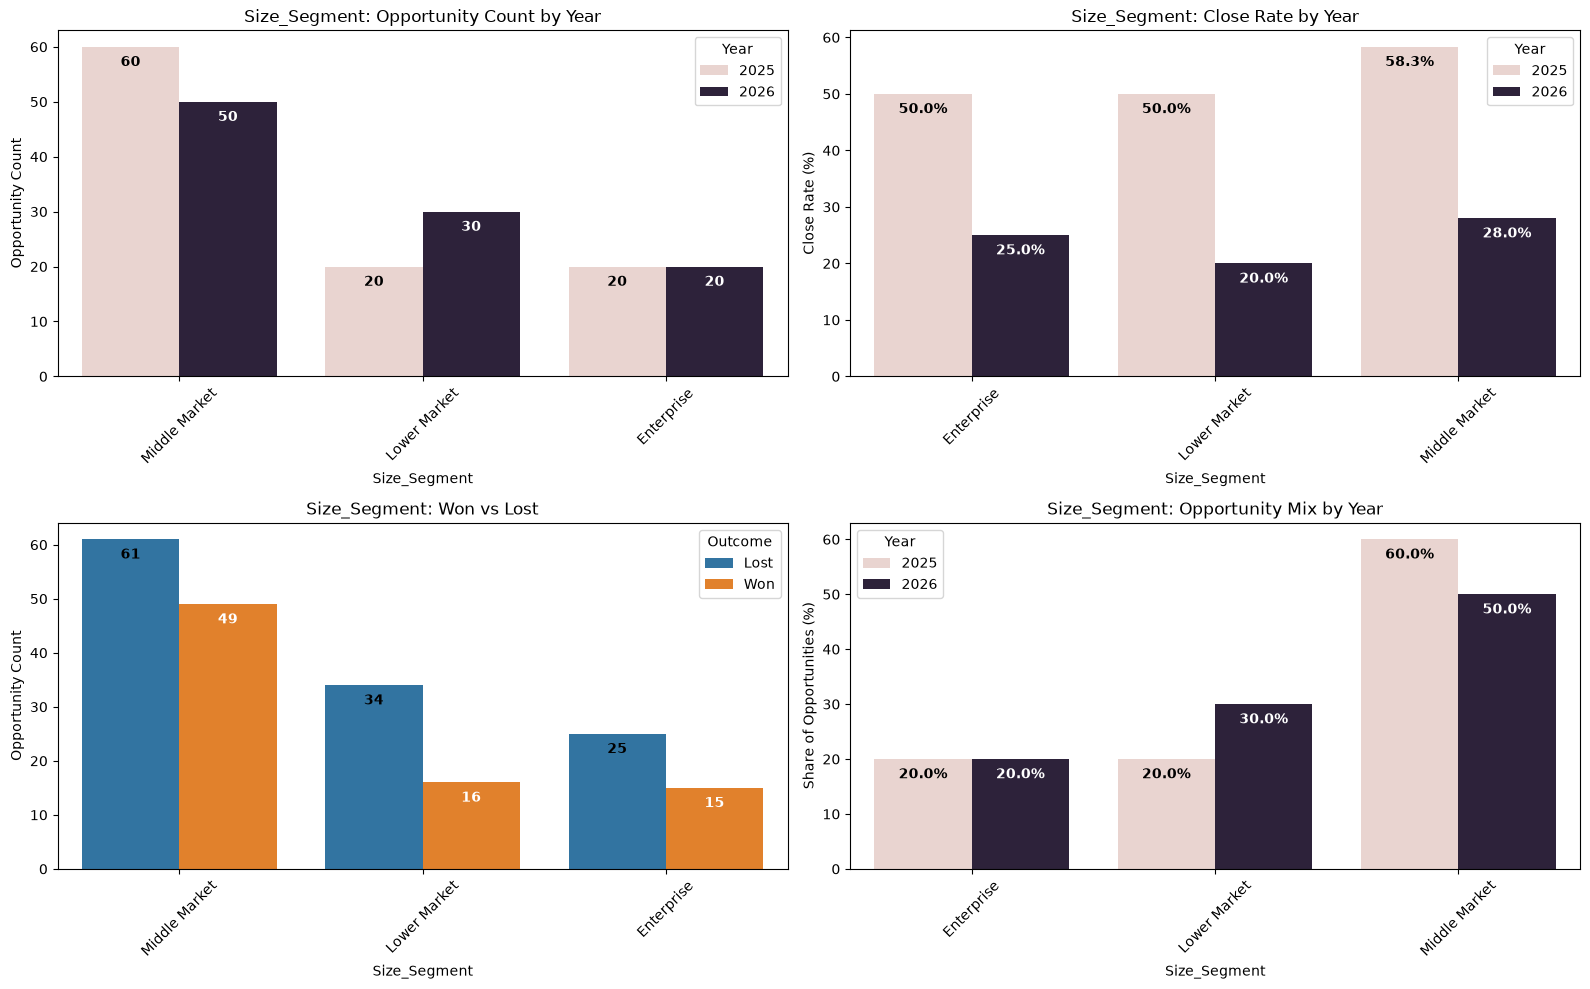

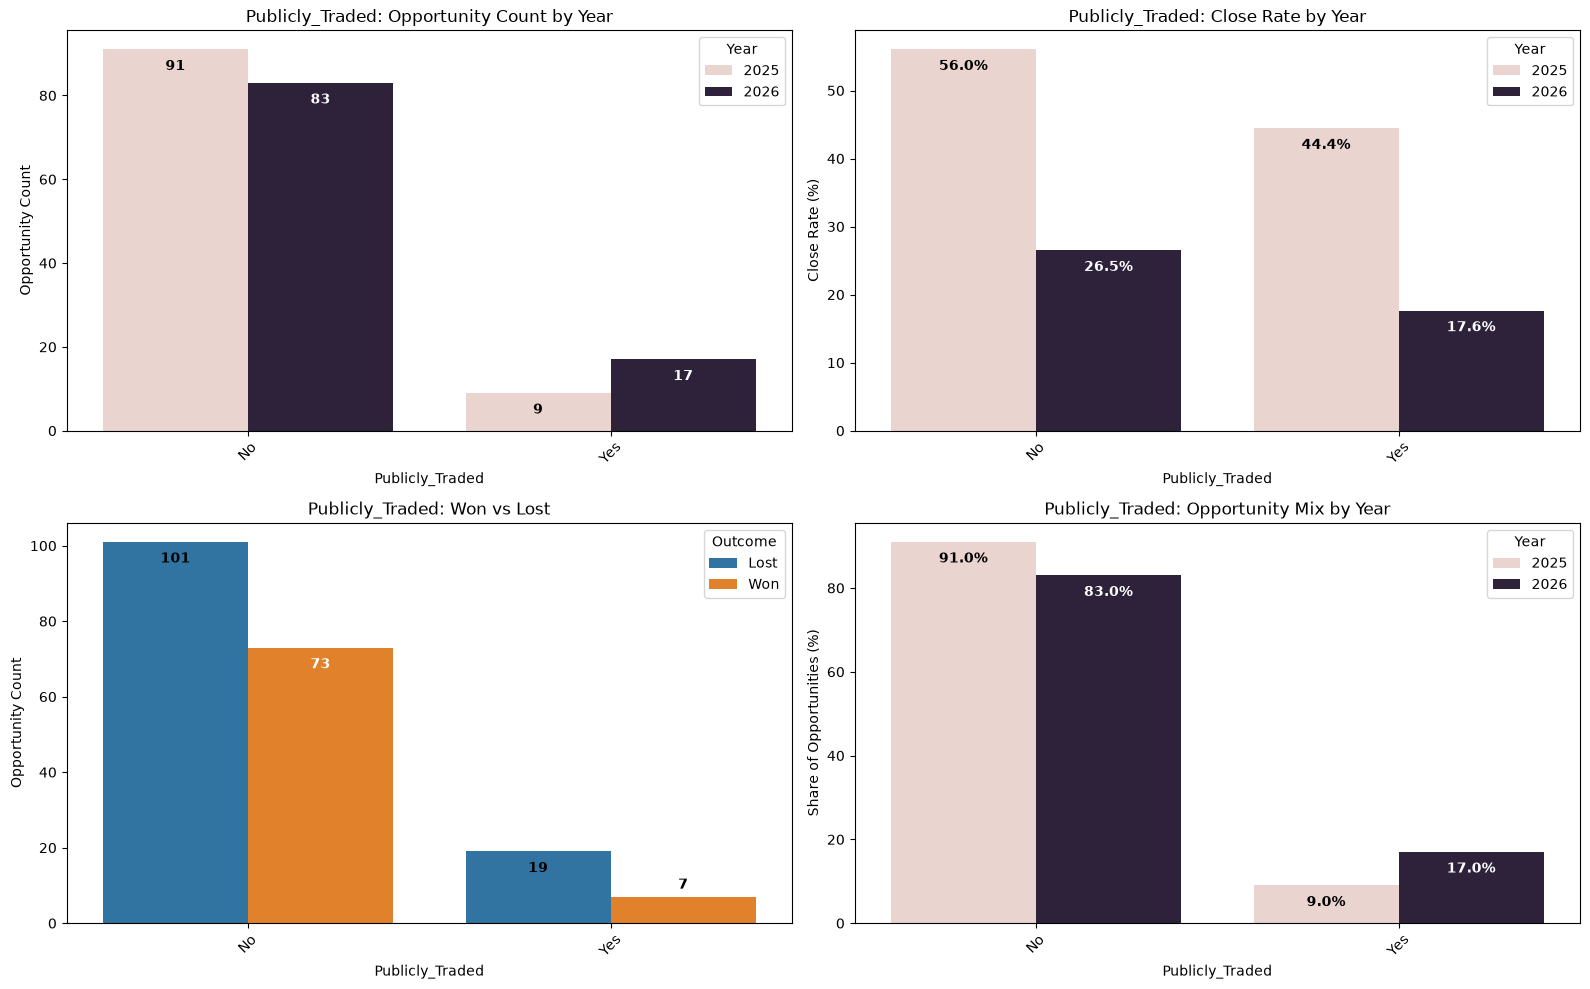

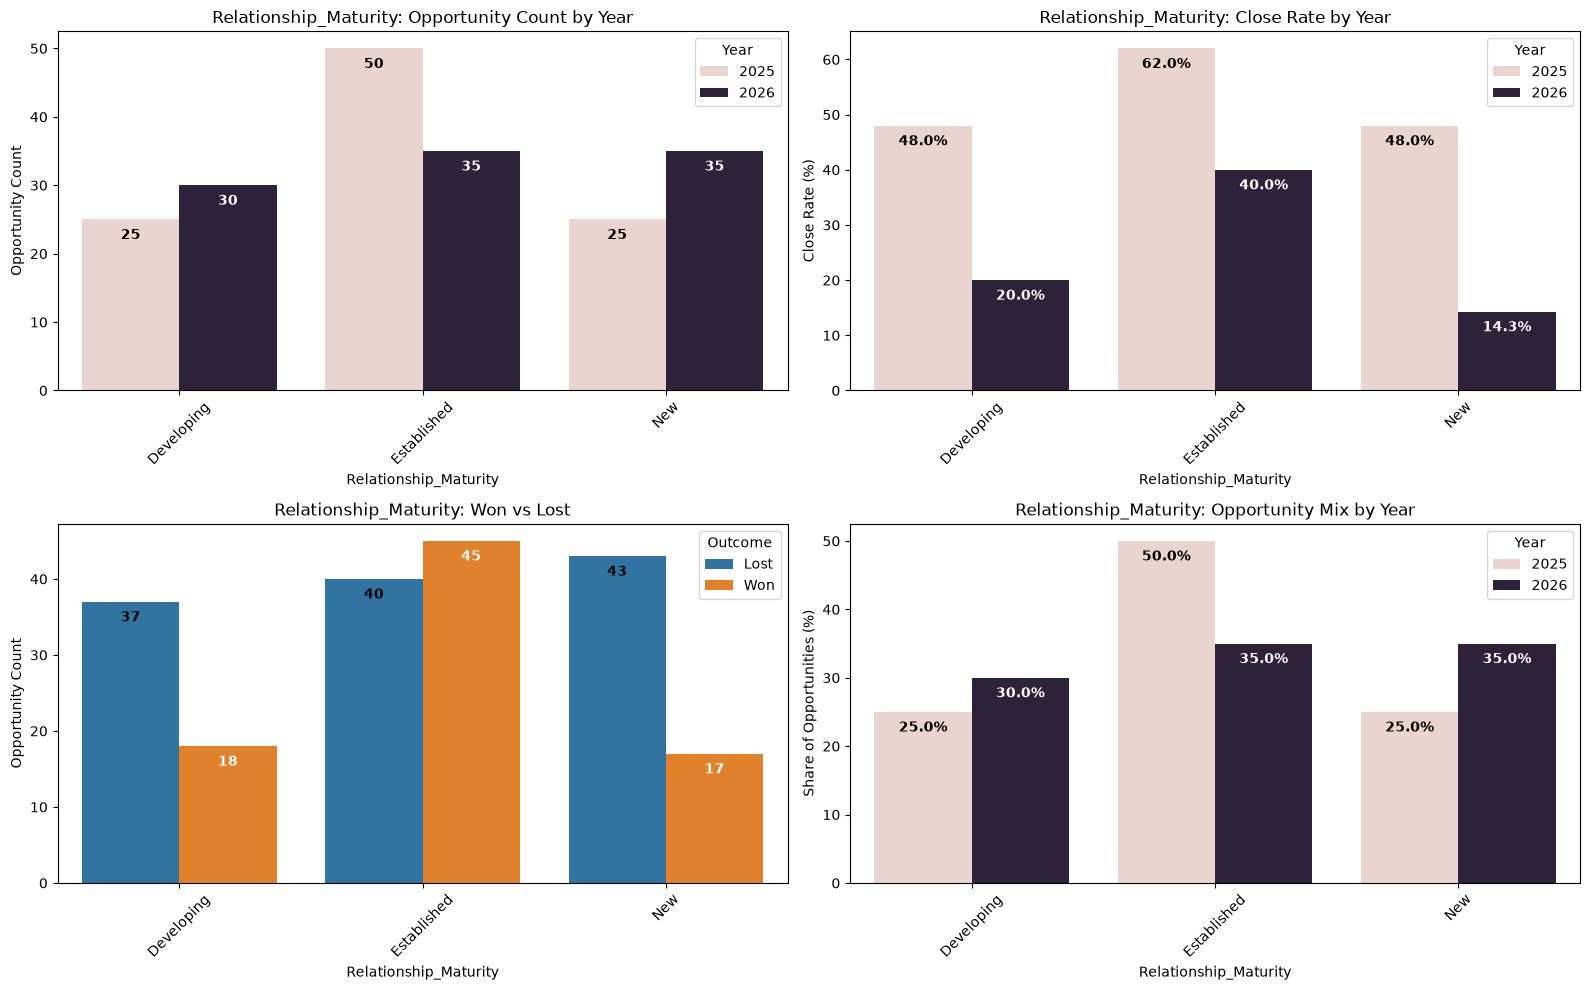

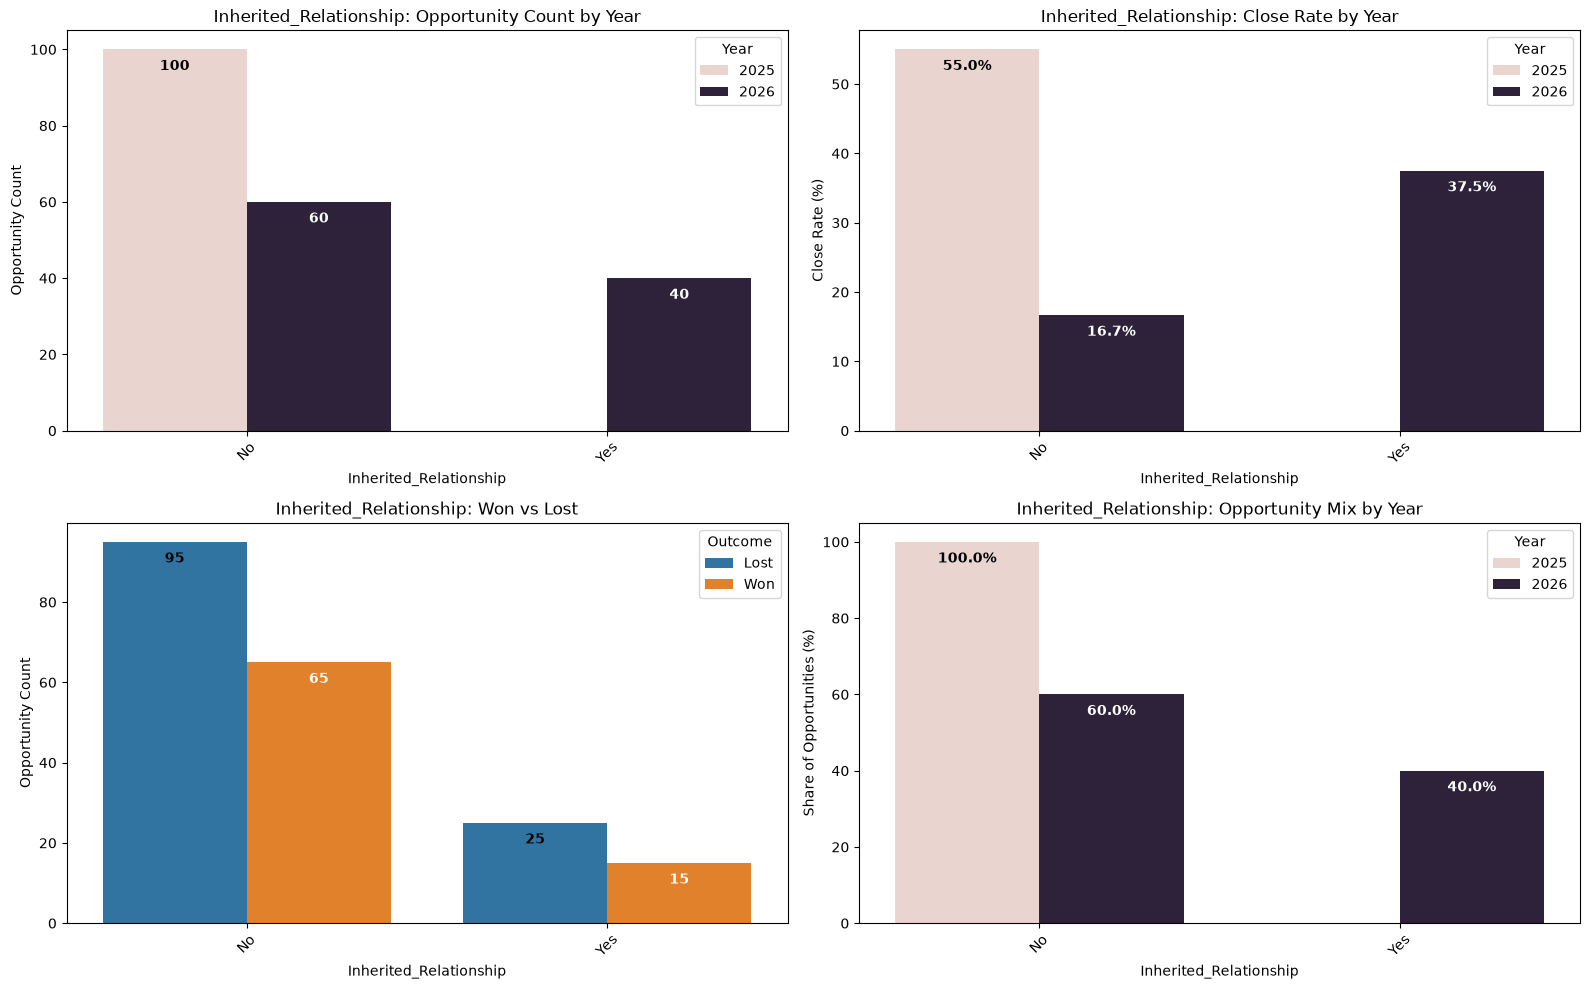

In [7]:
# ============================================================
# CATEGORICAL-DIMENSION EDA
# ============================================================
# For each categorical dimension, inspect:
# 1. Opportunity count by year
# 2. Close rate by category and year
# 3. Won/Lost count by category
# 4. Opportunity mix by year
#
# Each bar is labeled using the correct unit:
# Counts = whole numbers
# Rates / shares = percentages
# ============================================================


# ------------------------------------------------------------
# HELPER FUNCTION: ADD LEGIBLE BAR LABELS
# ------------------------------------------------------------

def add_bar_labels(ax, label_type="count"):

    # Loop through each bar container
    # Each hue level generally creates its own container
    for container_index, container in enumerate(ax.containers):

        # Alternate label color based on hue/bar color
        # First hue = light -> black text
        # Second hue = dark -> white text
        inside_color = (
            "black"
            if container_index == 0
            else "white"
        )

        for bar in container:

            height = bar.get_height()

            # Skip missing / NaN bars
            if pd.isna(height):
                continue

            # ----------------------------
            # Format label
            # ----------------------------

            if label_type == "count":
                label = f"{height:.0f}"

            elif label_type == "percent":
                label = f"{height:.1f}%"

            else:
                label = f"{height:.1f}"


            # ----------------------------
            # Determine label placement
            # ----------------------------

            y_min, y_max = ax.get_ylim()
            y_range = y_max - y_min

            # Put labels inside normal-sized bars
            if height > y_range * 0.08:

                y_position = height - (
                    y_range * 0.025
                )

                vertical_alignment = "top"

                text_color = inside_color

            # Put labels above very small bars
            else:

                y_position = height + (
                    y_range * 0.012
                )

                vertical_alignment = "bottom"

                text_color = "black"


            # ----------------------------
            # Draw label
            # ----------------------------

            ax.text(
                bar.get_x()
                + bar.get_width() / 2,
                y_position,
                label,
                ha="center",
                va=vertical_alignment,
                fontsize=10,
                fontweight="bold",
                color=text_color
            )


# ============================================================
# RUN CATEGORICAL EDA
# ============================================================

for var in categorical_vars:

    fig, axes = plt.subplots(
        2, 2,
        figsize=(16, 10)
    )


    # --------------------------------------------------------
    # 1. OPPORTUNITY COUNT BY CATEGORY AND YEAR
    # --------------------------------------------------------

    sns.countplot(
        data=df,
        x=var,
        hue="Year",
        ax=axes[0, 0]
    )

    axes[0, 0].set_title(
        f"{var}: Opportunity Count by Year"
    )

    axes[0, 0].set_ylabel(
        "Opportunity Count"
    )

    axes[0, 0].tick_params(
        axis="x",
        rotation=45
    )

    add_bar_labels(
        axes[0, 0],
        label_type="count"
    )


    # --------------------------------------------------------
    # 2. CLOSE RATE BY CATEGORY AND YEAR
    # --------------------------------------------------------

    close_rate = (
        df.groupby(
            ["Year", var],
            observed=True
        )["Won"]
        .mean()
        .reset_index()
    )

    close_rate["Close_Rate"] = (
        close_rate["Won"] * 100
    )

    sns.barplot(
        data=close_rate,
        x=var,
        y="Close_Rate",
        hue="Year",
        ax=axes[0, 1]
    )

    axes[0, 1].set_title(
        f"{var}: Close Rate by Year"
    )

    axes[0, 1].set_ylabel(
        "Close Rate (%)"
    )

    axes[0, 1].tick_params(
        axis="x",
        rotation=45
    )

    add_bar_labels(
        axes[0, 1],
        label_type="percent"
    )


    # --------------------------------------------------------
    # 3. WON VS LOST COUNT
    # --------------------------------------------------------

    sns.countplot(
        data=df,
        x=var,
        hue="Outcome",
        ax=axes[1, 0]
    )

    axes[1, 0].set_title(
        f"{var}: Won vs Lost"
    )

    axes[1, 0].set_ylabel(
        "Opportunity Count"
    )

    axes[1, 0].tick_params(
        axis="x",
        rotation=45
    )

    add_bar_labels(
        axes[1, 0],
        label_type="count"
    )


    # --------------------------------------------------------
    # 4. OPPORTUNITY MIX BY YEAR
    # --------------------------------------------------------

    category_share = (
        df.groupby(
            ["Year", var],
            observed=True
        )
        .size()
        .reset_index(name="Count")
    )

    category_share["Share"] = (
        category_share["Count"]
        /
        category_share
        .groupby("Year")["Count"]
        .transform("sum")
        * 100
    )

    sns.barplot(
        data=category_share,
        x=var,
        y="Share",
        hue="Year",
        ax=axes[1, 1]
    )

    axes[1, 1].set_title(
        f"{var}: Opportunity Mix by Year"
    )

    axes[1, 1].set_ylabel(
        "Share of Opportunities (%)"
    )

    axes[1, 1].tick_params(
        axis="x",
        rotation=45
    )

    add_bar_labels(
        axes[1, 1],
        label_type="percent"
    )


    # --------------------------------------------------------
    # FINISH FIGURE
    # --------------------------------------------------------

    plt.tight_layout()
    plt.show()

### Hypothesis Testing

Broad EDA identified the signals worth investigating. I then tested three specific business hypotheses:

**H1: Personnel / Relationship Disruption**  
Did personnel changes disrupt relationship continuity and contribute to lower close rates?

**H2: Engagement Composition**  
Did changes in the composition of sales engagement contribute to lower close rates?

**H3: Relative Pricing**  
Did deterioration in Company's relative pricing position contribute to lower close rates?

*These are observational tests. Association does not establish causation.*

In [9]:
# ============================================================
# H1: PERSONNEL DISRUPTION / RELATIONSHIP CONTINUITY
# ============================================================
# Prediction:
# If personnel changes materially damaged relationship
# continuity, inherited relationships should exhibit weaker
# close performance in 2026.
# ============================================================

h1_inherited = (
    df[df["Year"] == 2026]
    .groupby(
        "Inherited_Relationship",
        observed=True
    )
    .agg(
        Opportunities=("Won", "size"),
        Wins=("Won", "sum"),
        Close_Rate=("Won", "mean")
    )
    .reset_index()
)

h1_inherited["Close_Rate"] *= 100

print("2026 Close Rate by Inherited Relationship")
display(h1_inherited)


h1_maturity = (
    df[df["Year"] == 2026]
    .groupby(
        "Relationship_Maturity",
        observed=True
    )
    .agg(
        Opportunities=("Won", "size"),
        Wins=("Won", "sum"),
        Close_Rate=("Won", "mean")
    )
    .reset_index()
)

h1_maturity["Close_Rate"] *= 100

print("\n2026 Close Rate by Relationship Maturity")
display(h1_maturity)

2026 Close Rate by Inherited Relationship


,Inherited_Relationship,Opportunities,Wins,Close_Rate
0,No,60,10,16.666667
1,Yes,40,15,37.500000



2026 Close Rate by Relationship Maturity


,Relationship_Maturity,Opportunities,Wins,Close_Rate
0,Developing,30,6,20.000000
1,Established,35,14,40.000000
2,New,35,5,14.285714


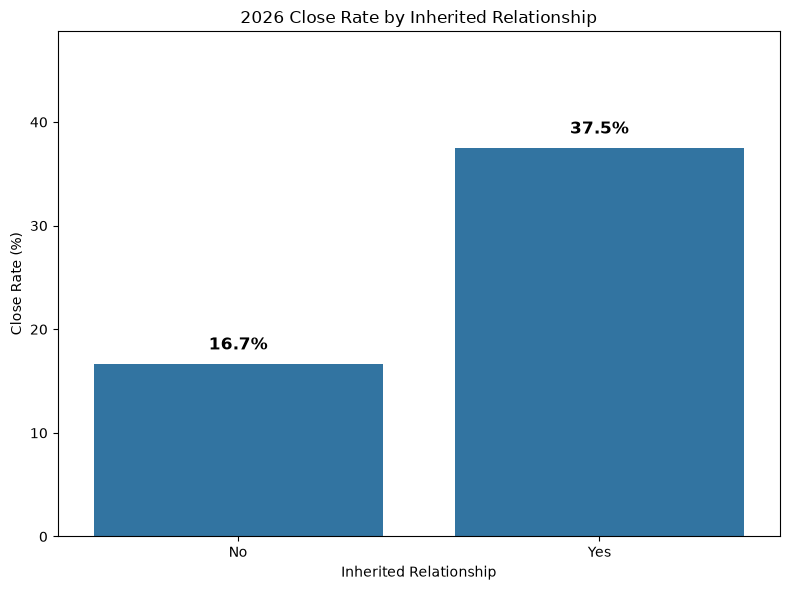

In [10]:
# ============================================================
# H1 DECISION VISUAL
# 2026 Close Rate: Inherited vs Non-Inherited Relationships
# ============================================================

plt.figure(figsize=(8, 6))

ax = sns.barplot(
    data=h1_inherited,
    x="Inherited_Relationship",
    y="Close_Rate"
)

ax.set_title(
    "2026 Close Rate by Inherited Relationship"
)

ax.set_xlabel(
    "Inherited Relationship"
)

ax.set_ylabel(
    "Close Rate (%)"
)

ax.set_ylim(
    0,
    max(h1_inherited["Close_Rate"]) * 1.30
)

for bar in ax.patches:

    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f"{height:.1f}%",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

In [11]:
# ============================================================
# H2: ENGAGEMENT COMPOSITION
# ============================================================
# Question:
# Is winning associated primarily with more total activity,
# or with a greater concentration of meaningful engagement?
# ============================================================

h2_activity = (
    df[df["Year"] == 2026]
    .groupby(
        "Outcome",
        observed=True
    )
    .agg(
        Meaningful_Engagements=(
            "Meaningful_Engagements",
            "mean"
        ),
        Low_Touch_Activities=(
            "Low_Touch_Activities",
            "mean"
        ),
        Total_Activities=(
            "Total_Activities",
            "mean"
        ),
        Meaningful_Engagement_Rate=(
            "Meaningful_Engagement_Rate",
            "mean"
        )
    )
    .reset_index()
)

display(h2_activity)

,Outcome,Meaningful_Engagements,Low_Touch_Activities,Total_Activities,Meaningful_Engagement_Rate
0,Lost,3.346667,7.586667,10.933333,0.287886
1,Won,5.000000,6.920000,11.920000,0.409346


In [13]:
# ============================================================
# H2 TEST:
# Divide 2026 opportunities into thirds based on
# Meaningful Engagement Rate.
# ============================================================

df_2026 = (
    df[df["Year"] == 2026]
    .copy()
)

df_2026["Engagement_Group"] = pd.qcut(
    df_2026["Meaningful_Engagement_Rate"],
    q=3,
    labels=[
        "Low",
        "Medium",
        "High"
    ]
)

h2_groups = (
    df_2026
    .groupby(
        "Engagement_Group",
        observed=True
    )
    .agg(
        Opportunities=("Won", "size"),
        Wins=("Won", "sum"),
        Close_Rate=("Won", "mean")
    )
    .reset_index()
)

h2_groups["Close_Rate"] *= 100

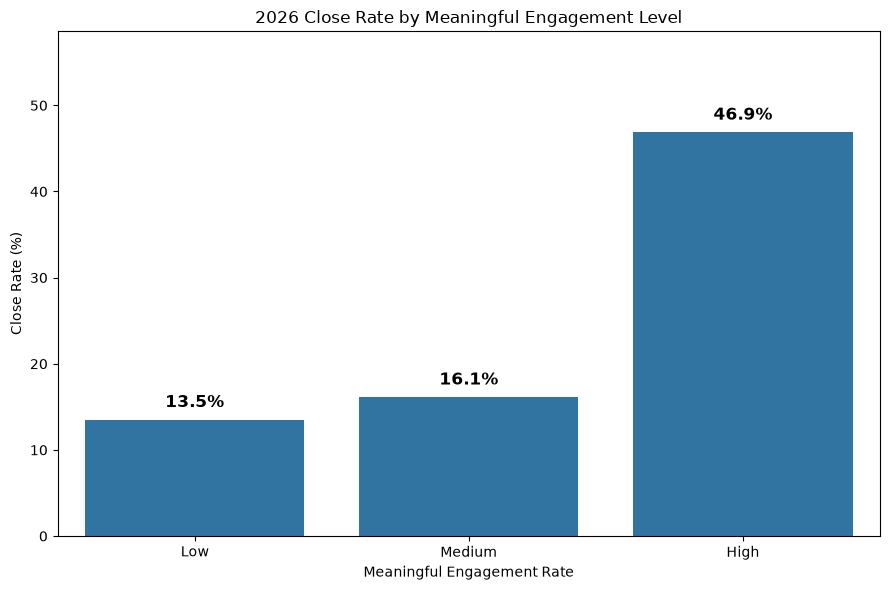

In [14]:
# ============================================================
# H2 DECISION VISUAL
# 2026 Close Rate by Meaningful Engagement Group
# ============================================================

plt.figure(figsize=(9, 6))

ax = sns.barplot(
    data=h2_groups,
    x="Engagement_Group",
    y="Close_Rate",
    order=[
        "Low",
        "Medium",
        "High"
    ]
)

ax.set_title(
    "2026 Close Rate by Meaningful Engagement Level"
)

ax.set_xlabel(
    "Meaningful Engagement Rate"
)

ax.set_ylabel(
    "Close Rate (%)"
)

ax.set_ylim(
    0,
    max(h2_groups["Close_Rate"]) * 1.25
)

for bar in ax.patches:

    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f"{height:.1f}%",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

In [15]:
# ============================================================
# H2 CHALLENGE TEST:
# Does 2026 new-product emphasis explain the outcome?
# ============================================================

h2_product = (
    df[df["Year"] == 2026]
    .groupby(
        "New_Product_Presented",
        observed=True
    )
    .agg(
        Opportunities=("Won", "size"),
        Wins=("Won", "sum"),
        Close_Rate=("Won", "mean")
    )
    .reset_index()
)

h2_product["Close_Rate"] *= 100

display(h2_product)

,New_Product_Presented,Opportunities,Wins,Close_Rate
0,No,33,8,24.242424
1,Yes,67,17,25.373134


In [16]:
# ============================================================
# H3: RELATIVE PRICING
# ============================================================
# Question:
# Were larger Company-vs-competitor rate differentials
# associated with lower 2026 close rates?
# ============================================================

h3_outcome = (
    df[df["Year"] == 2026]
    .groupby(
        "Outcome",
        observed=True
    )
    .agg(
        Opportunities=("Won", "size"),
        Average_Rate_Differential=(
            "Rate_Differential_Points",
            "mean"
        ),
        Median_Rate_Differential=(
            "Rate_Differential_Points",
            "median"
        )
    )
    .reset_index()
)

display(h3_outcome)

,Outcome,Opportunities,Average_Rate_Differential,Median_Rate_Differential
0,Lost,75,2.617867,2.72
1,Won,25,2.146400,2.25


In [17]:
# ============================================================
# H3 TEST:
# Group 2026 opportunities by relative pricing position.
# ============================================================

df_2026["Pricing_Gap"] = pd.cut(
    df_2026["Rate_Differential_Points"],
    bins=[
        -float("inf"),
        1.5,
        3.0,
        float("inf")
    ],
    labels=[
        "≤ 1.5 pts",
        "1.5–3.0 pts",
        "> 3.0 pts"
    ]
)

h3_pricing = (
    df_2026
    .groupby(
        "Pricing_Gap",
        observed=True
    )
    .agg(
        Opportunities=("Won", "size"),
        Wins=("Won", "sum"),
        Close_Rate=("Won", "mean")
    )
    .reset_index()
)

h3_pricing["Close_Rate"] *= 100

display(h3_pricing)

,Pricing_Gap,Opportunities,Wins,Close_Rate
0,≤ 1.5 pts,24,7,29.166667
1,1.5–3.0 pts,39,11,28.205128
2,> 3.0 pts,37,7,18.918919


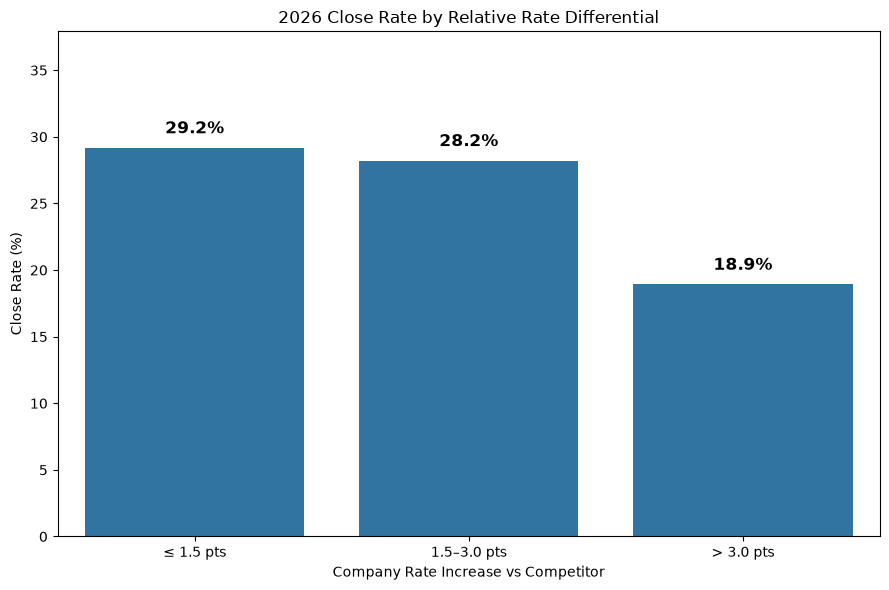

In [18]:
# ============================================================
# H3 DECISION VISUAL
# 2026 Close Rate by Relative Pricing Gap
# ============================================================

plt.figure(figsize=(9, 6))

ax = sns.barplot(
    data=h3_pricing,
    x="Pricing_Gap",
    y="Close_Rate"
)

ax.set_title(
    "2026 Close Rate by Relative Rate Differential"
)

ax.set_xlabel(
    "Company Rate Increase vs Competitor"
)

ax.set_ylabel(
    "Close Rate (%)"
)

ax.set_ylim(
    0,
    max(h3_pricing["Close_Rate"]) * 1.30
)

for bar in ax.patches:

    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.8,
        f"{height:.1f}%",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

# ============================================================
# HYPOTHESIS DECISION SUMMARY
# ============================================================

hypothesis_summary = pd.DataFrame({

    "Hypothesis": [
        "H1: Personnel / Relationship Disruption",
        "H2: Engagement Composition",
        "H3: Relative Pricing"
    ],

    "Key_Evidence": [
        (
            "Inherited relationships closed at 37.5% "
            "vs 16.7% for non-inherited relationships."
        ),
        (
            "High meaningful-engagement opportunities "
            "closed at 44.1% vs 12.1% for the low group."
        ),
        (
            "Opportunities with >3-point relative pricing "
            "gaps closed at 18.9% vs approximately 28–29% "
            "at smaller gaps."
        )
    ],

    "Interpretation": [
        "Expected relationship-disruption pattern not observed",
        "Strongest observed actionable association",
        "Directionally supported but weaker signal"
    ],

    "Decision": [
        "Deprioritize",
        "Prioritize",
        "Retain as secondary factor"
    ]
})

display(hypothesis_summary)

In [19]:
from IPython.display import display, Markdown

display(Markdown("""
## Hypothesis Decision

### H1: Personnel / Relationship Disruption
**Deprioritized**

The expected relationship-disruption pattern was not observed. In 2026, inherited relationships closed at **37.5%**, compared with **16.7%** for non-inherited relationships. Established relationships also produced the strongest close rate among relationship-maturity groups.

### H2: Engagement Composition
**Prioritized**

Engagement composition produced the strongest actionable relationship with 2026 outcomes. Opportunities with a **high Meaningful Engagement Rate closed at 44.1%**, compared with **18.2%** for the medium group and **12.1%** for the low group.

Total activity showed substantially less separation, suggesting that **how sales teams engage may matter more than activity volume alone**.

### H3: Relative Pricing
**Retained as a Secondary Factor**

Relative pricing showed a directionally consistent but weaker relationship with outcomes. Opportunities with a Company-to-competitor rate differential greater than **3 percentage points closed at 18.9%**, compared with approximately **28% to 29%** when the differential was 3 points or less.

### Decision

**Prioritize H2: Engagement Composition** as the primary hypothesis for intervention and further testing.

The analysis identifies **Meaningful Engagement Rate as the strongest actionable signal associated with winning in 2026**. H3 should continue to be monitored as a potential secondary contributor, while the available evidence does not support prioritizing H1.

These findings represent **associations, not causal effects**. The next step is to test whether deliberately increasing the share of meaningful engagement on qualified Large Group opportunities improves close rates.
"""))


## Hypothesis Decision

### H1: Personnel / Relationship Disruption
**Deprioritized**

The expected relationship-disruption pattern was not observed. In 2026, inherited relationships closed at **37.5%**, compared with **16.7%** for non-inherited relationships. Established relationships also produced the strongest close rate among relationship-maturity groups.

### H2: Engagement Composition
**Prioritized**

Engagement composition produced the strongest actionable relationship with 2026 outcomes. Opportunities with a **high Meaningful Engagement Rate closed at 44.1%**, compared with **18.2%** for the medium group and **12.1%** for the low group.

Total activity showed substantially less separation, suggesting that **how sales teams engage may matter more than activity volume alone**.

### H3: Relative Pricing
**Retained as a Secondary Factor**

Relative pricing showed a directionally consistent but weaker relationship with outcomes. Opportunities with a Company-to-competitor rate differential greater than **3 percentage points closed at 18.9%**, compared with approximately **28% to 29%** when the differential was 3 points or less.

### Decision

**Prioritize H2: Engagement Composition** as the primary hypothesis for intervention and further testing.

The analysis identifies **Meaningful Engagement Rate as the strongest actionable signal associated with winning in 2026**. H3 should continue to be monitored as a potential secondary contributor, while the available evidence does not support prioritizing H1.

These findings represent **associations, not causal effects**. The next step is to test whether deliberately increasing the share of meaningful engagement on qualified Large Group opportunities improves close rates.


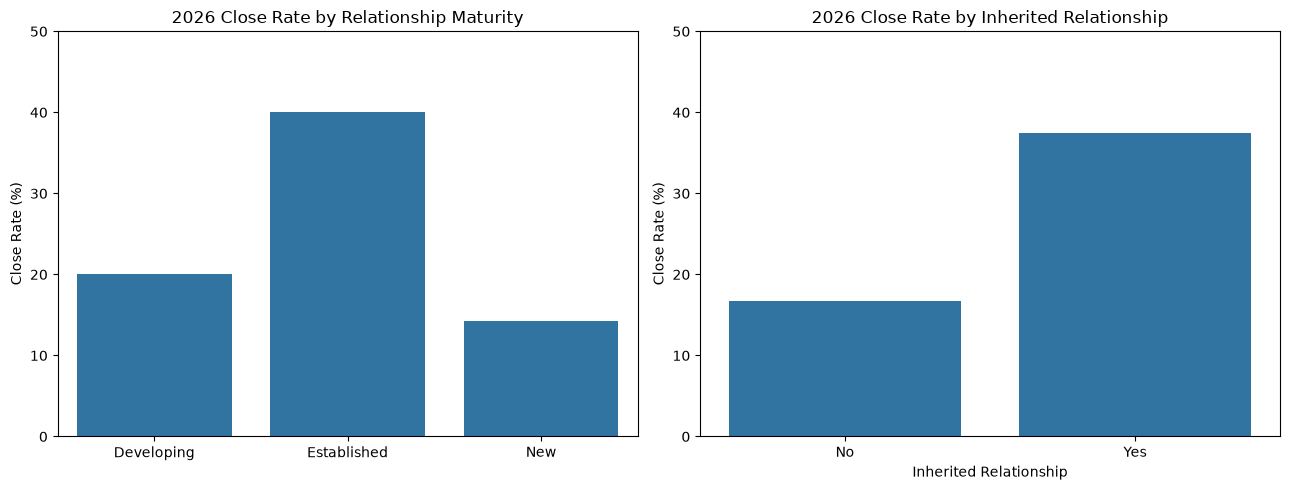

,Relationship_Maturity,Opportunities,Close_Rate
0,Developing,30,20.0
1,Established,35,40.0
2,New,35,14.3


,Inherited_Relationship,Opportunities,Close_Rate
0,No,60,16.7
1,Yes,40,37.5


In [20]:
# H1B — Relationship evidence in 2026

h1_2026 = df[df["Year"] == 2026].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

maturity = (
    h1_2026.groupby("Relationship_Maturity", observed=True)
           .agg(Opportunities=("Won", "size"), Close_Rate=("Won", "mean"))
           .reset_index()
)
maturity["Close_Rate"] *= 100

sns.barplot(
    data=maturity,
    x="Relationship_Maturity",
    y="Close_Rate",
    ax=axes[0]
)
axes[0].set_title("2026 Close Rate by Relationship Maturity")
axes[0].set_xlabel("")
axes[0].set_ylabel("Close Rate (%)")
axes[0].set_ylim(0, 50)

inherited = (
    h1_2026.groupby("Inherited_Relationship", observed=True)
           .agg(Opportunities=("Won", "size"), Close_Rate=("Won", "mean"))
           .reset_index()
)
inherited["Close_Rate"] *= 100

sns.barplot(
    data=inherited,
    x="Inherited_Relationship",
    y="Close_Rate",
    ax=axes[1]
)
axes[1].set_title("2026 Close Rate by Inherited Relationship")
axes[1].set_xlabel("Inherited Relationship")
axes[1].set_ylabel("Close Rate (%)")
axes[1].set_ylim(0, 50)

plt.tight_layout()
plt.show()

display(maturity.round(1))
display(inherited.round(1))


### H1 Readout

The SPIFF period coincides with unusually strong 2025 conversion, so timing deserves attention. However, Q4 2025 returns to the same 40% close rate as Q1 rather than showing an immediate collapse, and opportunity volume is held constant in the synthetic design. That means the data are **consistent with** pull-forward but do not demonstrate depletion.

Relationship maturity matters in 2026, but inherited relationships actually close at a higher rate than non-inherited relationships in this dataset. That weakens the specific claim that inherited relationships themselves caused the decline.


## H2 — Changing Opportunity & Engagement Mix

**Test:** Did the composition of seller activity change, and did meaningful engagement become more strongly associated with winning than total activity or low-touch activity?


,Total_Activities,Meaningful_Engagements,Low_Touch_Activities,Meaningful_Engagement_Rate
Year,,,,
2025,9.85,3.85,6.00,0.37
2026,11.18,3.76,7.42,0.32


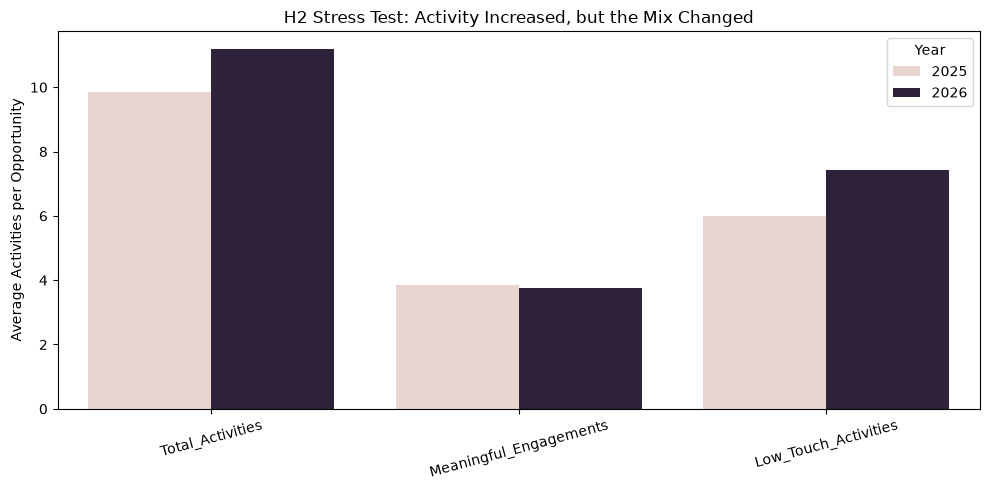

In [21]:
# H2A — Quantity of activity versus quality/composition of engagement

engagement_year = (
    df.groupby("Year")
      .agg(
          Total_Activities=("Total_Activities", "mean"),
          Meaningful_Engagements=("Meaningful_Engagements", "mean"),
          Low_Touch_Activities=("Low_Touch_Activities", "mean"),
          Meaningful_Engagement_Rate=("Meaningful_Engagement_Rate", "mean")
      )
      .round(2)
)

display(engagement_year)

engagement_long = (
    engagement_year[
        ["Total_Activities", "Meaningful_Engagements", "Low_Touch_Activities"]
    ]
    .reset_index()
    .melt(id_vars="Year", var_name="Activity_Type", value_name="Average_per_Opportunity")
)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=engagement_long,
    x="Activity_Type",
    y="Average_per_Opportunity",
    hue="Year"
)
plt.title("H2 Stress Test: Activity Increased, but the Mix Changed")
plt.xlabel("")
plt.ylabel("Average Activities per Opportunity")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


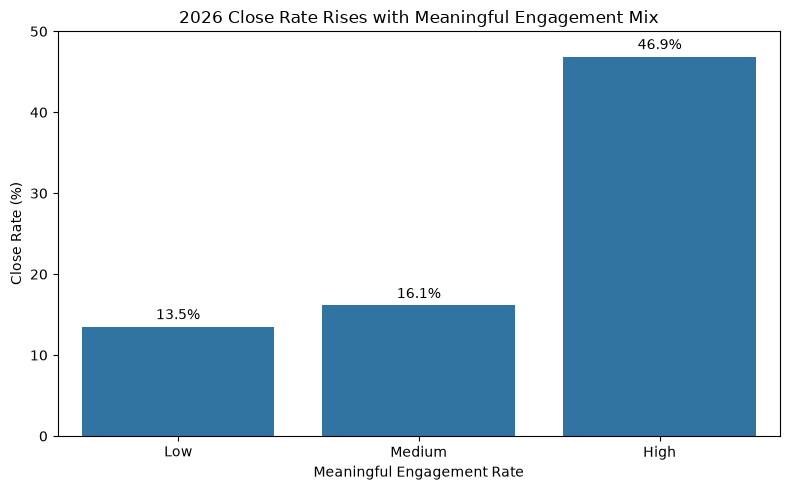

,Engagement_Rate_Tertile,Opportunities,Wins,Close_Rate
0,Low,37,5,13.5
1,Medium,31,5,16.1
2,High,32,15,46.9


In [22]:
# H2B — 2026 close rate by meaningful-engagement-rate tertile

h2_2026 = df[df["Year"] == 2026].copy()

h2_2026["Engagement_Rate_Tertile"] = pd.qcut(
    h2_2026["Meaningful_Engagement_Rate"],
    q=3,
    labels=["Low", "Medium", "High"],
    duplicates="drop"
)

engagement_tiers = (
    h2_2026.groupby("Engagement_Rate_Tertile", observed=True)
           .agg(
               Opportunities=("Won", "size"),
               Wins=("Won", "sum"),
               Close_Rate=("Won", "mean")
           )
           .reset_index()
)

engagement_tiers["Close_Rate"] *= 100

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=engagement_tiers,
    x="Engagement_Rate_Tertile",
    y="Close_Rate",
    order=["Low", "Medium", "High"]
)
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.title("2026 Close Rate Rises with Meaningful Engagement Mix")
plt.xlabel("Meaningful Engagement Rate")
plt.ylabel("Close Rate (%)")
plt.ylim(0, 50)
plt.tight_layout()
plt.show()

display(engagement_tiers.round(1))


,Total_Activities,Meaningful_Engagements,Low_Touch_Activities,Meaningful_Engagement_Rate
Outcome,,,,
Lost,10.93,3.35,7.59,0.29
Won,11.92,5.00,6.92,0.41


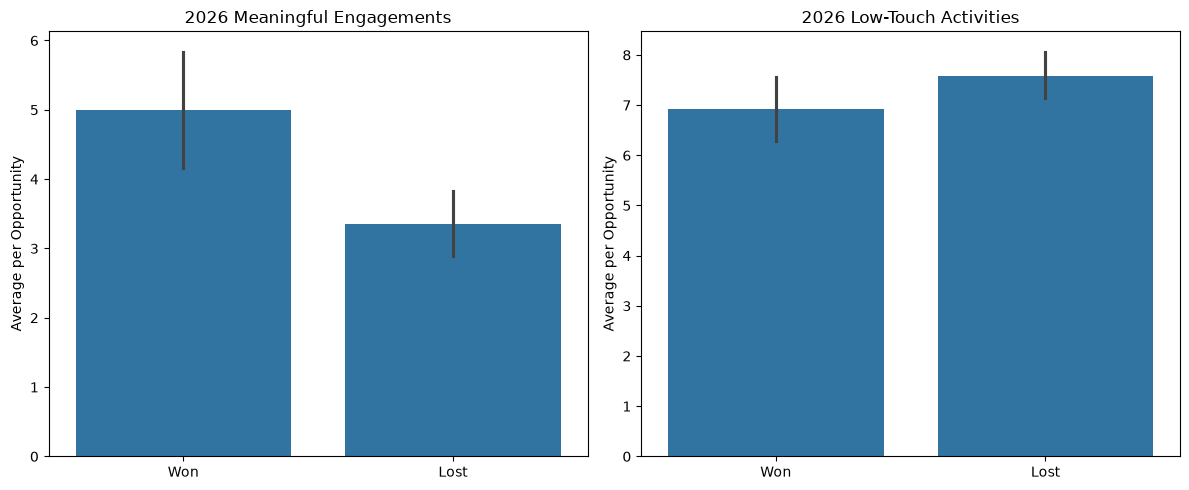

In [23]:
# H2C — Won vs Lost: meaningful engagement, low-touch activity, and total activity

h2_outcome = (
    h2_2026.groupby("Outcome")
           .agg(
               Total_Activities=("Total_Activities", "mean"),
               Meaningful_Engagements=("Meaningful_Engagements", "mean"),
               Low_Touch_Activities=("Low_Touch_Activities", "mean"),
               Meaningful_Engagement_Rate=("Meaningful_Engagement_Rate", "mean")
           )
           .round(2)
)

display(h2_outcome)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(
    data=h2_2026,
    x="Outcome",
    y="Meaningful_Engagements",
    ax=axes[0]
)
axes[0].set_title("2026 Meaningful Engagements")
axes[0].set_xlabel("")
axes[0].set_ylabel("Average per Opportunity")

sns.barplot(
    data=h2_2026,
    x="Outcome",
    y="Low_Touch_Activities",
    ax=axes[1]
)
axes[1].set_title("2026 Low-Touch Activities")
axes[1].set_xlabel("")
axes[1].set_ylabel("Average per Opportunity")

plt.tight_layout()
plt.show()


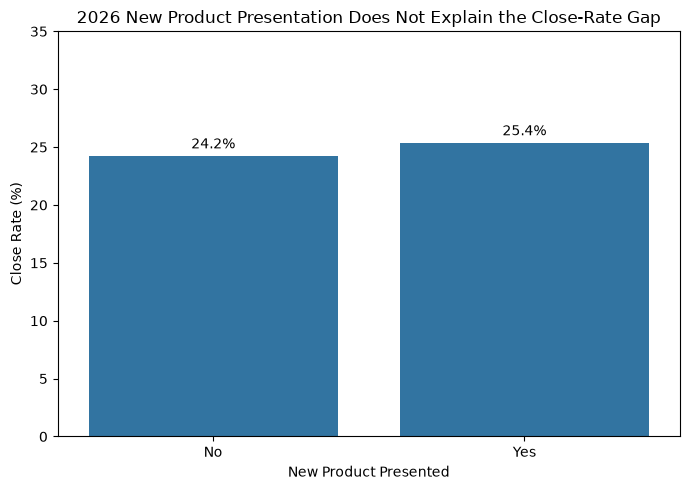

,New_Product_Presented,Opportunities,Wins,Close_Rate
0,No,33,8,24.2
1,Yes,67,17,25.4


In [24]:
# H2D — Check whether the 2026 new-product emphasis explains the result

product_test = (
    h2_2026.groupby("New_Product_Presented", observed=True)
           .agg(
               Opportunities=("Won", "size"),
               Wins=("Won", "sum"),
               Close_Rate=("Won", "mean")
           )
           .reset_index()
)

product_test["Close_Rate"] *= 100

plt.figure(figsize=(7, 5))
ax = sns.barplot(
    data=product_test,
    x="New_Product_Presented",
    y="Close_Rate"
)
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.title("2026 New Product Presentation Does Not Explain the Close-Rate Gap")
plt.xlabel("New Product Presented")
plt.ylabel("Close Rate (%)")
plt.ylim(0, 35)
plt.tight_layout()
plt.show()

display(product_test.round(1))


### H2 Readout

The strongest broad-screen changes cluster around engagement. In 2026, opportunities in the highest third of meaningful-engagement rate close materially more often than those in the lower thirds. Total activity itself is much less discriminating, while low-touch activity is negatively associated with winning.

The 2026 new-product emphasis does not meaningfully separate wins from losses, so the supported portion of H2 is **engagement composition**, not simply product emphasis.


## H3 — Relative Pricing Deterioration

**Test:** Is a larger Company-versus-competitor rate differential associated with lower 2026 conversion?


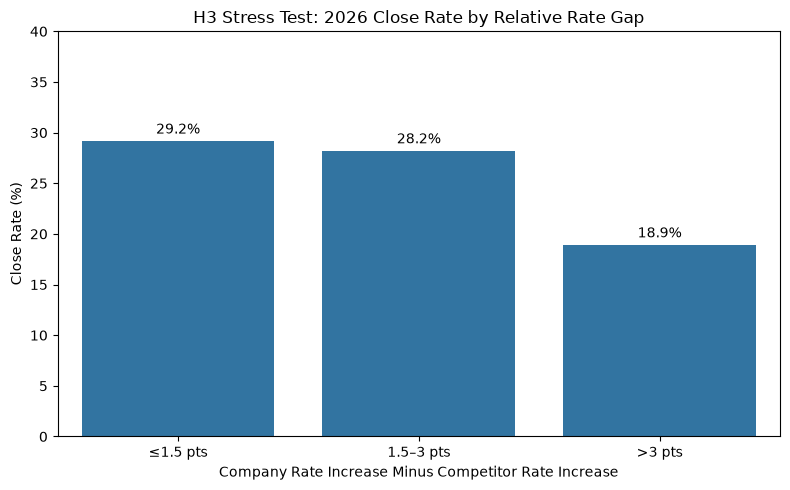

,Rate_Gap_Band,Opportunities,Wins,Close_Rate
0,≤1.5 pts,24,7,29.2
1,1.5–3 pts,39,11,28.2
2,>3 pts,37,7,18.9


In [25]:
# H3 — 2026 close rate by relative pricing band

h3_2026 = df[df["Year"] == 2026].copy()

h3_2026["Rate_Gap_Band"] = pd.cut(
    h3_2026["Rate_Differential_Points"],
    bins=[-np.inf, 1.5, 3.0, np.inf],
    labels=["≤1.5 pts", "1.5–3 pts", ">3 pts"]
)

pricing_bands = (
    h3_2026.groupby("Rate_Gap_Band", observed=True)
           .agg(
               Opportunities=("Won", "size"),
               Wins=("Won", "sum"),
               Close_Rate=("Won", "mean")
           )
           .reset_index()
)

pricing_bands["Close_Rate"] *= 100

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=pricing_bands,
    x="Rate_Gap_Band",
    y="Close_Rate"
)
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.title("H3 Stress Test: 2026 Close Rate by Relative Rate Gap")
plt.xlabel("Company Rate Increase Minus Competitor Rate Increase")
plt.ylabel("Close Rate (%)")
plt.ylim(0, 40)
plt.tight_layout()
plt.show()

display(pricing_bands.round(1))


### H3 Readout

Pricing shows the expected directional pattern: the widest relative rate gaps close less often. But the 2026 univariate association is modest compared with the meaningful-engagement signal, and competitively priced opportunities still lose. Pricing remains a plausible secondary contributor rather than the strongest explanation in this synthetic sample.


# Hypothesis Decision

**Primary supported hypothesis: H2 — Changing Opportunity & Engagement Mix, specifically the engagement-composition component.**

Why it advances:
- The broad, hypothesis-agnostic screen surfaced multiple related engagement measures near the top rather than a single isolated variable.
- In 2026, the highest third of meaningful-engagement rate closes substantially more often than the lower thirds.
- Meaningful engagements separate Won from Lost opportunities more clearly than total activity.
- The pattern is actionable: leadership can influence seller behavior and engagement mix.

Why H1 does not advance as the primary explanation:
- The 2025 SPIFF timing pattern is suggestive, but the available fields cannot prove opportunities were pulled forward.
- Q4 2025 does not show an immediate post-SPIFF collapse.
- Inherited relationships outperform non-inherited relationships in 2026, weakening the specific inheritance-disruption mechanism.

Why H3 does not advance as the primary explanation:
- Wider relative rate gaps are associated with lower conversion, but the relationship is weaker than the engagement signal.
- Pricing is therefore retained as an alternative contributor to monitor and test.

**Inference, not causation:** The synthetic EDA supports prioritizing meaningful engagement as the leading intervention target. It does not establish that increasing meaningful engagement causes a win.


# Decision-Ready Recommendation and Validation

**Primary recommendation:** Pilot a Large Group sales-process intervention designed to increase the share of meaningful engagement within qualified opportunities, rather than simply increasing total sales activity.

**Why this is the priority:** Engagement composition produced the strongest actionable signal in the analysis. In 2026, opportunities in the high Meaningful Engagement Rate group closed at **46.9%**, compared with **16.1%** for the medium group and **13.5%** for the low group. Total activity showed substantially less separation between Won and Lost opportunities, suggesting the opportunity is not simply generating more activity, but shifting activity toward higher-value customer engagement.

**How to test the recommendation:** Phase the intervention across comparable qualified opportunities or seller groups while maintaining a comparable control or baseline group. Predefine **Meaningful Engagement Rate** as the primary process metric and **Close Rate** as the primary business outcome. Measure whether the intervention increases meaningful engagement and, more importantly, whether improved engagement is followed by a measurable improvement in close rate.

**Secondary factor to monitor:** Continue monitoring relative pricing. Opportunities with a Company-to-competitor rate differential greater than **3 percentage points closed at 18.9%**, compared with approximately **28% to 29%** when the differential was 3 points or less. Pricing therefore remains a plausible secondary contributor, particularly at wider competitive gaps.

**Deprioritized hypothesis:** Personnel-driven relationship disruption is not supported by the observed pattern. Inherited relationships closed at **37.5%**, compared with **16.7%** for non-inherited relationships, while established relationships produced the strongest close rate among relationship-maturity groups.

**Validation standard:** These results identify associations, not causal effects. The pilot should determine whether deliberately increasing Meaningful Engagement Rate actually produces higher close rates before the intervention is scaled broadly.